In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import json
import warnings
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

warnings.filterwarnings("ignore")
load_dotenv()

plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#e6edf3",
    "axes.titlecolor":   "#e6edf3",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "text.color":        "#e6edf3",
    "grid.color":        "#21262d",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "figure.titlesize":  16,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
    "legend.labelcolor": "#e6edf3",
})

COLORS = {
    "bangkok": "#f97316",
    "lisbon":  "#3b82f6",
    "accent":  "#a78bfa",
    "positive":"#22c55e",
    "negative":"#ef4444",
    "neutral": "#8b949e",
}

PALETTE_BKK  = sns.color_palette("YlOrRd",  8)
PALETTE_LIS  = sns.color_palette("Blues",   8)
PALETTE_BOTH = [COLORS["bangkok"], COLORS["lisbon"]]

print("Libraries loaded successfully.")
print(f"Matplotlib backend: {plt.get_backend()}")

def get_engine():
    host     = os.getenv("DB_HOST",     "localhost")
    port     = os.getenv("DB_PORT",     "5432")
    name     = os.getenv("DB_NAME",     "airbnb_analytics")
    user     = os.getenv("DB_USER",     "postgres")
    password = os.getenv("DB_PASSWORD", "postgres")
    url = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}"
    return create_engine(url)

engine = get_engine()

def query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("Database connection established.")
print("\nLoading data from PostgreSQL...")

listings = query("""
    SELECT f.*, h.host_is_superhost, h.host_tenure_years as host_years,
           h.is_commercial_host, h.host_response_rate, h.host_acceptance_rate,
           h.host_response_time
    FROM fact_listings f
    LEFT JOIN dim_host h ON f.host_id = h.host_id AND f.city = h.city
""")

reviews = query("""
    SELECT * FROM fact_reviews
""")

calendar = query("""
    SELECT listing_id, city, date, available, is_weekend, month, year, year_month
    FROM fact_calendar
""")

print(f"listings:  {len(listings):,} rows")
print(f"reviews:   {len(reviews):,} rows")
print(f"calendar:  {len(calendar):,} rows")

# Split by city for easy access
bkk = listings[listings["city"] == "bangkok"].copy()
lis = listings[listings["city"] == "lisbon"].copy()

print(f"\nBangkok listings:  {len(bkk):,}")
print(f"Lisbon listings:   {len(lis):,}")

Libraries loaded successfully.
Matplotlib backend: module://matplotlib_inline.backend_inline
Database connection established.

Loading data from PostgreSQL...
listings:  53,756 rows
reviews:   2,414,998 rows
calendar:  19,621,081 rows

Bangkok listings:  28,806
Lisbon listings:   24,950


In [6]:

print("SUMMARY STATISTICS")

# Key metrics we care about
numeric_cols = [
    "price", "minimum_nights", "number_of_reviews",
    "review_scores_rating", "occupancy_rate",
    "estimated_annual_revenue", "host_tenure_years",
    "review_score_composite", "availability_365"
]

print("\n--- BANGKOK ---")
bkk_stats = bkk[numeric_cols].describe().round(2)
print(bkk_stats.to_string())

print("\n--- LISBON ---")
lis_stats = lis[numeric_cols].describe().round(2)
print(lis_stats.to_string())

# Side by side comparison of key metrics
comparison = pd.DataFrame({
    "Metric": [
        "Total Listings",
        "Median Price",
        "Mean Occupancy Rate (%)",
        "Median Annual Revenue",
        "Avg Review Score",
        "Median Min Nights",
        "Avg Reviews per Listing",
        "Median Host Tenure (years)"
    ],
    "Bangkok": [
        f"{len(bkk):,}",
        f"฿{bkk['price'].median():,.0f}",
        f"{bkk['occupancy_rate'].mean():.1f}%",
        f"฿{bkk['estimated_annual_revenue'].median():,.0f}",
        f"{bkk['review_scores_rating'].mean():.3f}",
        f"{bkk['minimum_nights'].median():.0f}",
        f"{bkk['number_of_reviews'].mean():.1f}",
        f"{bkk['host_tenure_years'].median():.1f}"
    ],
    "Lisbon": [
        f"{len(lis):,}",
        f"€{lis['price'].median():,.0f}",
        f"{lis['occupancy_rate'].mean():.1f}%",
        f"€{lis['estimated_annual_revenue'].median():,.0f}",
        f"{lis['review_scores_rating'].mean():.3f}",
        f"{lis['minimum_nights'].median():.0f}",
        f"{lis['number_of_reviews'].mean():.1f}",
        f"{lis['host_tenure_years'].median():.1f}"
    ]
})

print("\n")
print("=" * 60)
print("CITY COMPARISON — KEY METRICS")
print("=" * 60)
print(comparison.to_string(index=False))

SUMMARY STATISTICS

--- BANGKOK ---
            price  minimum_nights  number_of_reviews  review_scores_rating  occupancy_rate  estimated_annual_revenue  host_tenure_years  review_score_composite  availability_365
count    23273.00        28806.00           28806.00              18716.00        28806.00              2.327300e+04           28797.00                18716.00          28806.00
mean      2528.75           14.11              20.25                  4.69           31.47              2.030144e+05               6.32                    4.71            250.05
std      16473.90           43.24              54.80                  0.54           34.59              2.341271e+06               3.81                    0.46            126.35
min          4.00            1.00               0.00                  0.00            0.00              0.000000e+00               0.01                    1.00              0.00
25%        923.00            1.00               0.00                  4.64

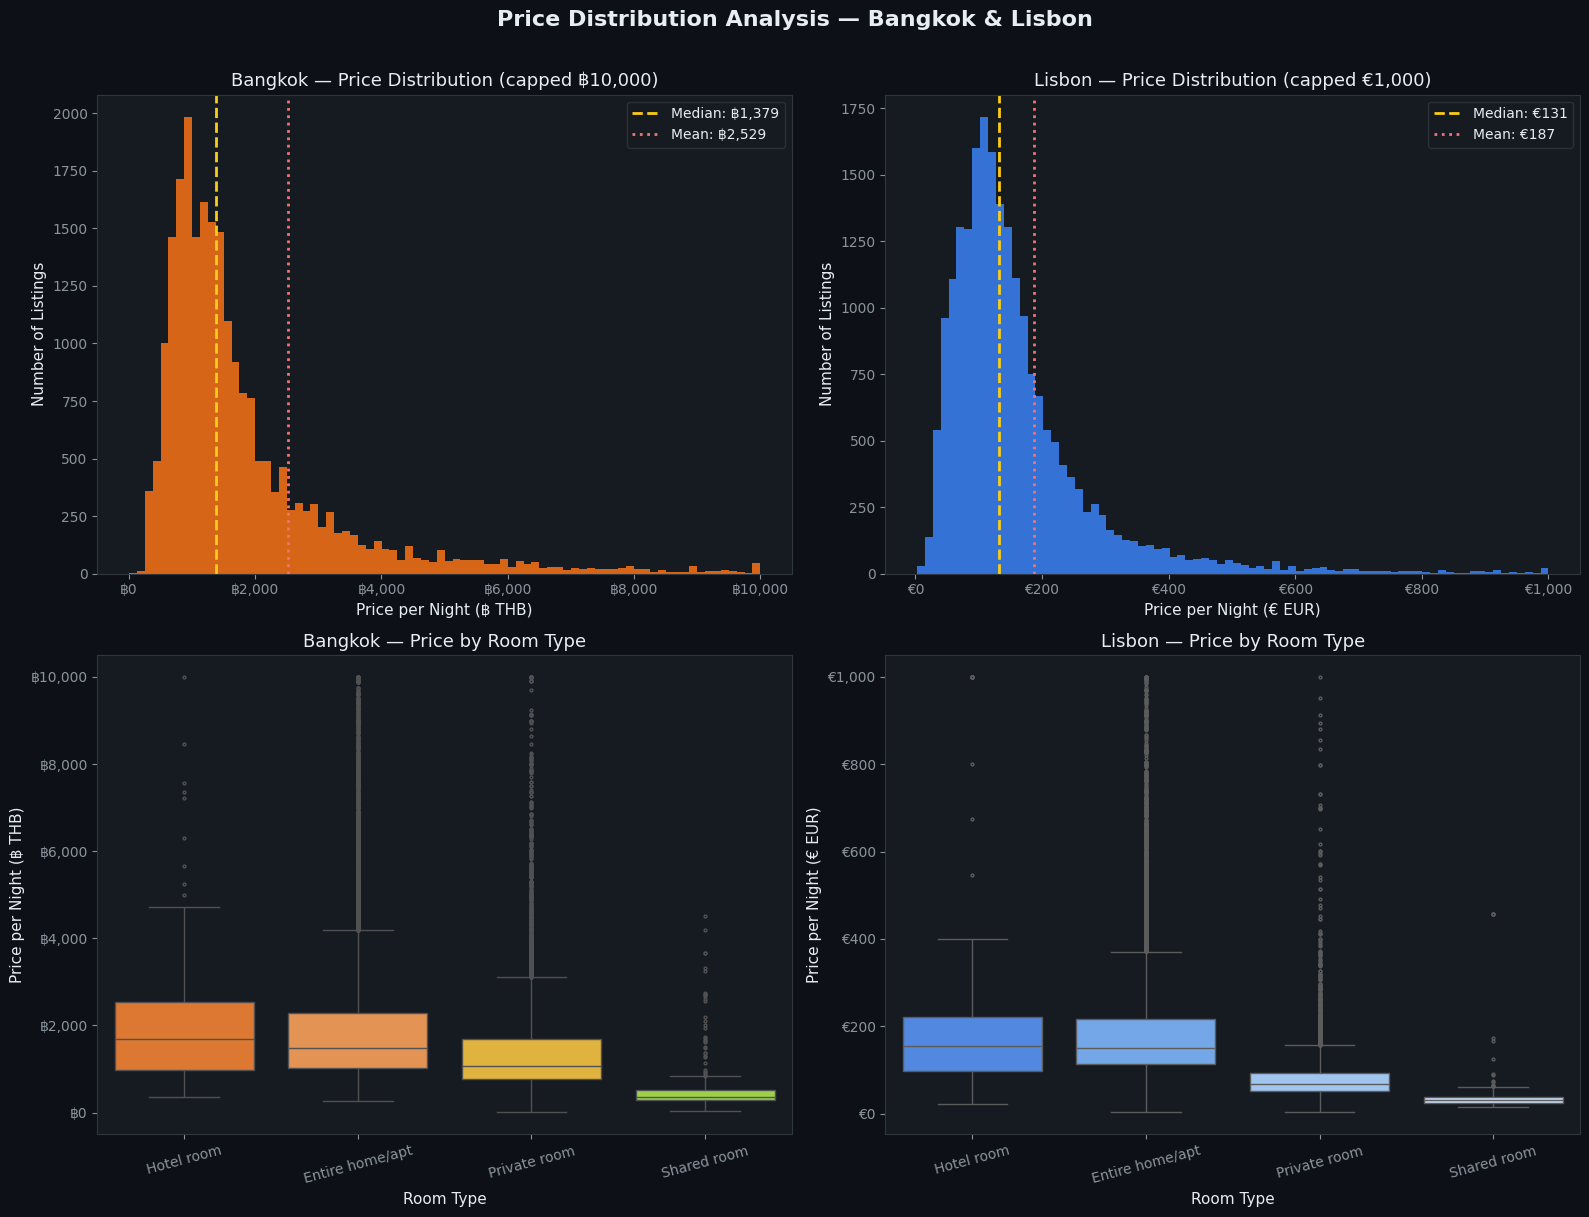

Chart 1 saved.


In [8]:
#Price Distribution

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Price Distribution Analysis — Bangkok & Lisbon", 
             fontsize=16, fontweight="bold", y=1.01)

# bangkok
ax1 = axes[0, 0]
bkk_prices = bkk["price"].dropna()
bkk_capped = bkk_prices[bkk_prices <= 10000]
ax1.hist(bkk_capped, bins=80, color=COLORS["bangkok"], alpha=0.85, edgecolor="none")
ax1.axvline(bkk_prices.median(), color="#facc15", linewidth=2, 
            linestyle="--", label=f"Median: ฿{bkk_prices.median():,.0f}")
ax1.axvline(bkk_prices.mean(), color="#f87171", linewidth=2, 
            linestyle=":", label=f"Mean: ฿{bkk_prices.mean():,.0f}")
ax1.set_title("Bangkok — Price Distribution (capped ฿10,000)")
ax1.set_xlabel("Price per Night (฿ THB)")
ax1.set_ylabel("Number of Listings")
ax1.legend()
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"฿{x:,.0f}"))

# Lisbon price distribution
ax2 = axes[0, 1]
lis_prices = lis["price"].dropna()
lis_capped = lis_prices[lis_prices <= 1000]
ax2.hist(lis_capped, bins=80, color=COLORS["lisbon"], alpha=0.85, edgecolor="none")
ax2.axvline(lis_prices.median(), color="#facc15", linewidth=2,
            linestyle="--", label=f"Median: €{lis_prices.median():,.0f}")
ax2.axvline(lis_prices.mean(), color="#f87171", linewidth=2,
            linestyle=":", label=f"Mean: €{lis_prices.mean():,.0f}")
ax2.set_title("Lisbon — Price Distribution (capped €1,000)")
ax2.set_xlabel("Price per Night (€ EUR)")
ax2.set_ylabel("Number of Listings")
ax2.legend()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

#Price by room type : Bangkok 
ax3 = axes[1, 0]
room_order = bkk.groupby("room_type")["price"].median().sort_values(ascending=False).index
bkk_room = bkk[bkk["price"] <= 10000]
room_colors = [COLORS["bangkok"], "#fb923c", "#fbbf24", "#a3e635"]
sns.boxplot(data=bkk_room, x="room_type", y="price", order=room_order,
            palette=room_colors, ax=ax3, fliersize=2)
ax3.set_title("Bangkok — Price by Room Type")
ax3.set_xlabel("Room Type")
ax3.set_ylabel("Price per Night (฿ THB)")
ax3.tick_params(axis="x", rotation=15)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"฿{x:,.0f}"))

#Price by room type: Lisbon 
ax4 = axes[1, 1]
room_order_l = lis.groupby("room_type")["price"].median().sort_values(ascending=False).index
lis_room = lis[lis["price"] <= 1000]
room_colors_l = [COLORS["lisbon"], "#60a5fa", "#93c5fd", "#bfdbfe"]
sns.boxplot(data=lis_room, x="room_type", y="price", order=room_order_l,
            palette=room_colors_l, ax=ax4, fliersize=2)
ax4.set_title("Lisbon — Price by Room Type")
ax4.set_xlabel("Room Type")
ax4.set_ylabel("Price per Night (€ EUR)")
ax4.tick_params(axis="x", rotation=15)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

plt.tight_layout()
plt.savefig("01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

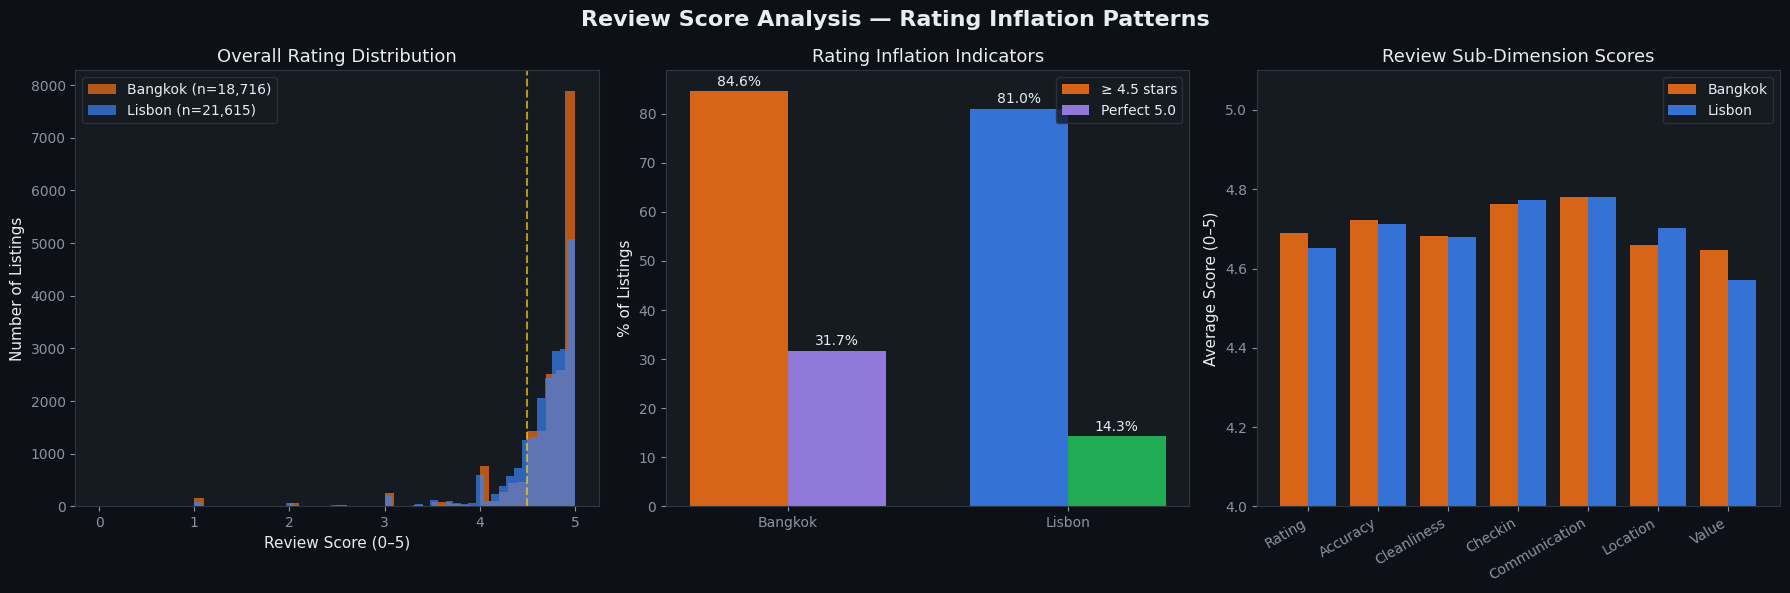

Chart 2 saved.


In [10]:
#Review Score Distributions — Rating Inflation Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Review Score Analysis — Rating Inflation Patterns", 
             fontsize=16, fontweight="bold")

# Overall rating distribution london and lisbon
ax1 = axes[0]
bkk_ratings = bkk["review_scores_rating"].dropna()
lis_ratings = lis["review_scores_rating"].dropna()

ax1.hist(bkk_ratings, bins=50, color=COLORS["bangkok"], alpha=0.7, 
         label=f"Bangkok (n={len(bkk_ratings):,})", edgecolor="none")
ax1.hist(lis_ratings, bins=50, color=COLORS["lisbon"], alpha=0.7,
         label=f"Lisbon (n={len(lis_ratings):,})", edgecolor="none")
ax1.set_title("Overall Rating Distribution")
ax1.set_xlabel("Review Score (0–5)")
ax1.set_ylabel("Number of Listings")
ax1.legend()
ax1.axvline(4.5, color="#facc15", linewidth=1.5, linestyle="--", 
            label="4.5 threshold", alpha=0.7)

#  % of listings above 4.5 rating 
ax2 = axes[1]
cities = ["Bangkok", "Lisbon"]
pct_above_45 = [
    (bkk_ratings >= 4.5).mean() * 100,
    (lis_ratings >= 4.5).mean() * 100
]
pct_perfect = [
    (bkk_ratings == 5.0).mean() * 100,
    (lis_ratings == 5.0).mean() * 100
]

x = np.arange(len(cities))
width = 0.35
bars1 = ax2.bar(x - width/2, pct_above_45, width, 
                color=PALETTE_BOTH, alpha=0.85, label="≥ 4.5 stars")
bars2 = ax2.bar(x + width/2, pct_perfect, width,
                color=[COLORS["accent"], COLORS["positive"]], 
                alpha=0.85, label="Perfect 5.0")
ax2.set_title("Rating Inflation Indicators")
ax2.set_ylabel("% of Listings")
ax2.set_xticks(x)
ax2.set_xticklabels(cities)
ax2.legend()
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

# Review sub-dimension comparison
ax3 = axes[2]
sub_dims = ["rating", "accuracy", "cleanliness", "checkin", 
            "communication", "location", "value"]
bkk_means = [bkk[f"review_scores_{d}"].mean() for d in sub_dims]
lis_means  = [lis[f"review_scores_{d}"].mean() for d in sub_dims]

x3 = np.arange(len(sub_dims))
ax3.bar(x3 - 0.2, bkk_means, 0.4, color=COLORS["bangkok"], 
        alpha=0.85, label="Bangkok")
ax3.bar(x3 + 0.2, lis_means,  0.4, color=COLORS["lisbon"],  
        alpha=0.85, label="Lisbon")
ax3.set_title("Review Sub-Dimension Scores")
ax3.set_ylabel("Average Score (0–5)")
ax3.set_xticks(x3)
ax3.set_xticklabels([d.capitalize() for d in sub_dims], rotation=30, ha="right")
ax3.set_ylim(4.0, 5.1)
ax3.legend()

plt.tight_layout()
plt.savefig("02_review_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")


Bangkok Market Concentration:
  Total unique hosts:          8,874
  Multi-listing hosts:         3,309 (37.3%)
  Listings by multi-hosts:     80.7%
  Top 10% hosts control:       55.9% of all listings

Lisbon Market Concentration:
  Total unique hosts:          9,715
  Multi-listing hosts:         3,291 (33.9%)
  Listings by multi-hosts:     74.3%
  Top 10% hosts control:       49.5% of all listings


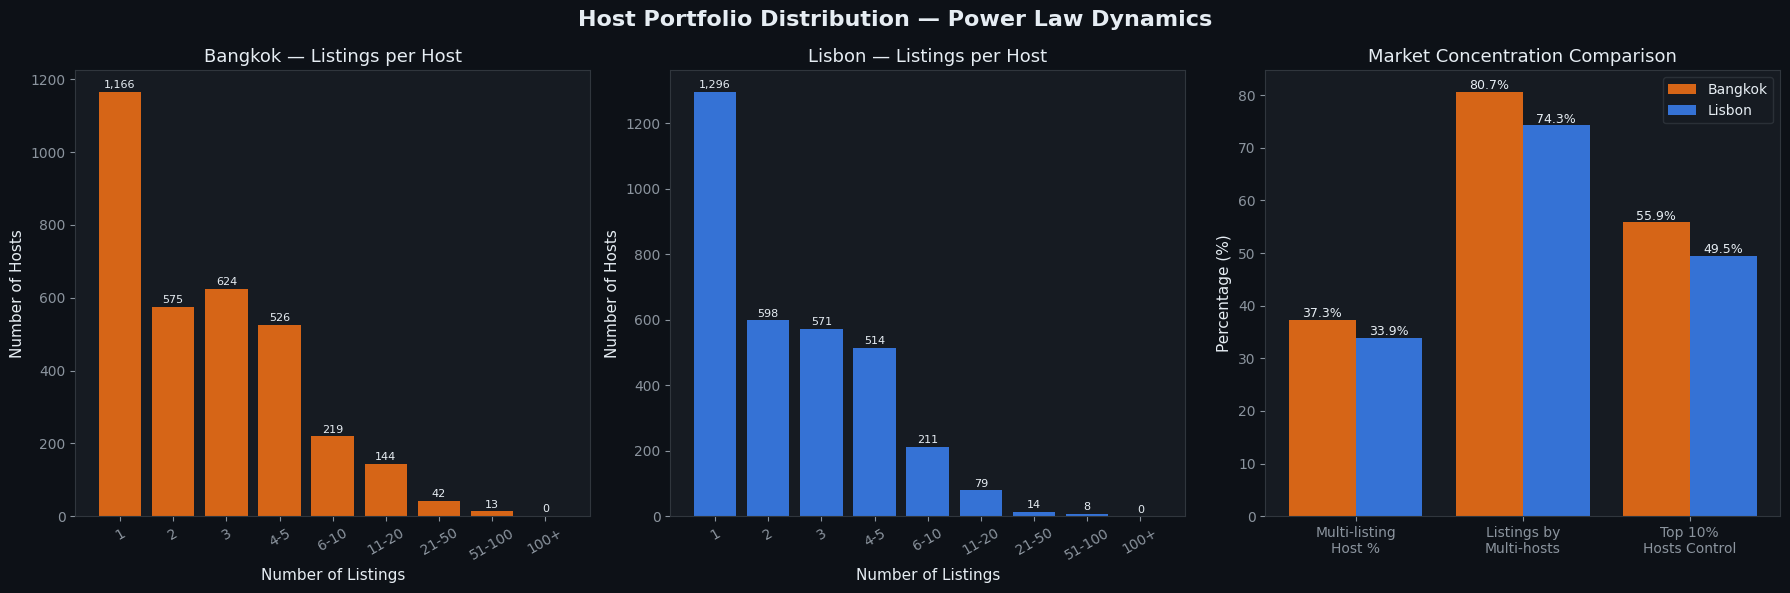


Chart 3 saved.


In [11]:
#Power Law Dynamics — Host Portfolio Size

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Host Portfolio Distribution — Power Law Dynamics", 
             fontsize=16, fontweight="bold")

for ax, df, city, color in zip(
    axes[:2],
    [bkk, lis],
    ["Bangkok", "Lisbon"],
    [COLORS["bangkok"], COLORS["lisbon"]]
):
    host_counts = df.groupby("host_id")["listing_id"].count().reset_index()
    host_counts.columns = ["host_id", "listing_count"]

    bins = [1, 2, 3, 5, 10, 20, 50, 100, 500, 9999]
    labels = ["1", "2", "3", "4-5", "6-10", "11-20", "21-50", "51-100", "100+"]
    host_counts["bucket"] = pd.cut(
        host_counts["listing_count"], bins=bins, labels=labels, right=True)
    
    bucket_counts = host_counts["bucket"].value_counts().sort_index()
    
    bars = ax.bar(range(len(bucket_counts)), bucket_counts.values, 
                  color=color, alpha=0.85, edgecolor="none")
    ax.set_xticks(range(len(bucket_counts)))
    ax.set_xticklabels(bucket_counts.index, rotation=30)
    ax.set_title(f"{city} — Listings per Host")
    ax.set_xlabel("Number of Listings")
    ax.set_ylabel("Number of Hosts")
    
    # Annotate bars
    for bar, val in zip(bars, bucket_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{val:,}", ha="center", va="bottom", fontsize=8)

#Market concentration comparison
ax3 = axes[2]
concentration_data = []
for df, city in [(bkk, "Bangkok"), (lis, "Lisbon")]:
    host_listing_counts = df.groupby("host_id").size().sort_values(ascending=False)
    total_listings = len(df)
    total_hosts = len(host_listing_counts)
    
    top10_pct_hosts = int(total_hosts * 0.10)
    top10_listings = host_listing_counts.iloc[:top10_pct_hosts].sum()
    top10_share = top10_listings / total_listings * 100
    
    multi_hosts = (host_listing_counts > 1).sum()
    multi_listings = host_listing_counts[host_listing_counts > 1].sum()
    
    concentration_data.append({
        "City": city,
        "Total Hosts": total_hosts,
        "Multi-listing Hosts": multi_hosts,
        "Multi-listing Host %": f"{multi_hosts/total_hosts*100:.1f}%",
        "Listings by Multi-hosts": f"{multi_listings/total_listings*100:.1f}%",
        "Top 10% hosts control": f"{top10_share:.1f}% of listings"
    })
    
    print(f"\n{city} Market Concentration:")
    print(f"  Total unique hosts:          {total_hosts:,}")
    print(f"  Multi-listing hosts:         {multi_hosts:,} ({multi_hosts/total_hosts*100:.1f}%)")
    print(f"  Listings by multi-hosts:     {multi_listings/total_listings*100:.1f}%")
    print(f"  Top 10% hosts control:       {top10_share:.1f}% of all listings")

# Concentration bar chart
metrics = ["Multi-listing\nHost %", "Listings by\nMulti-hosts", "Top 10%\nHosts Control"]
bkk_vals = [
    bkk.groupby("host_id").size().apply(lambda x: x > 1).mean() * 100,
    bkk[bkk["is_commercial_host"] == True].shape[0] / len(bkk) * 100,
    bkk.groupby("host_id").size().sort_values(ascending=False).iloc[:int(len(bkk.groupby("host_id").size()) * 0.10)].sum() / len(bkk) * 100
]
lis_vals = [
    lis.groupby("host_id").size().apply(lambda x: x > 1).mean() * 100,
    lis[lis["is_commercial_host"] == True].shape[0] / len(lis) * 100,
    lis.groupby("host_id").size().sort_values(ascending=False).iloc[:int(len(lis.groupby("host_id").size()) * 0.10)].sum() / len(lis) * 100
]

x = np.arange(len(metrics))
ax3.bar(x - 0.2, bkk_vals, 0.4, color=COLORS["bangkok"], alpha=0.85, label="Bangkok")
ax3.bar(x + 0.2, lis_vals, 0.4, color=COLORS["lisbon"],  alpha=0.85, label="Lisbon")
ax3.set_title("Market Concentration Comparison")
ax3.set_ylabel("Percentage (%)")
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
for i, (bv, lv) in enumerate(zip(bkk_vals, lis_vals)):
    ax3.text(i - 0.2, bv + 0.5, f"{bv:.1f}%", ha="center", fontsize=9)
    ax3.text(i + 0.2, lv + 0.5, f"{lv:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("03_power_law.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 3 saved.")

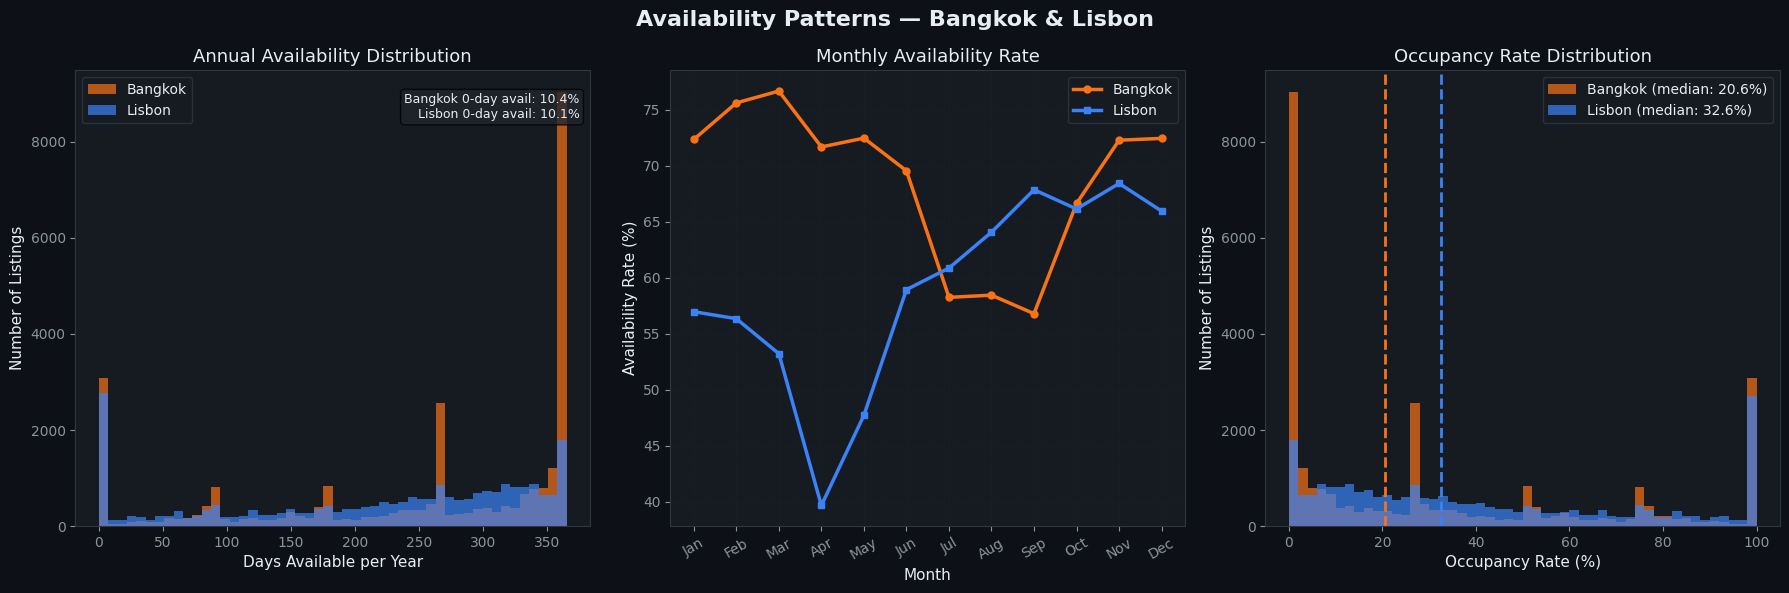

Chart 4 saved.


In [12]:
# Availability Patterns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Availability Patterns — Bangkok & Lisbon", 
             fontsize=16, fontweight="bold")

# Availability 365 distribution 
ax1 = axes[0]
ax1.hist(bkk["availability_365"].dropna(), bins=50, color=COLORS["bangkok"],
         alpha=0.7, label="Bangkok", edgecolor="none")
ax1.hist(lis["availability_365"].dropna(), bins=50, color=COLORS["lisbon"],
         alpha=0.7, label="Lisbon", edgecolor="none")
ax1.set_title("Annual Availability Distribution")
ax1.set_xlabel("Days Available per Year")
ax1.set_ylabel("Number of Listings")
ax1.legend()

bkk_zero = (bkk["availability_365"] == 0).mean() * 100
lis_zero  = (lis["availability_365"] == 0).mean() * 100
ax1.text(0.98, 0.95, 
         f"Bangkok 0-day avail: {bkk_zero:.1f}%\nLisbon 0-day avail: {lis_zero:.1f}%",
         transform=ax1.transAxes, ha="right", va="top",
         fontsize=9, color="#e6edf3",
         bbox=dict(boxstyle="round", facecolor="#21262d", alpha=0.8))

#Monthly availability from calendar
ax2 = axes[1]
bkk_cal = calendar[calendar["city"] == "bangkok"]
lis_cal  = calendar[calendar["city"] == "lisbon"]

bkk_monthly = bkk_cal.groupby("month")["available"].mean() * 100
lis_monthly  = lis_cal.groupby("month")["available"].mean() * 100

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

ax2.plot(range(1, 13), bkk_monthly.reindex(range(1, 13)),
         color=COLORS["bangkok"], linewidth=2.5, marker="o", 
         markersize=5, label="Bangkok")
ax2.plot(range(1, 13), lis_monthly.reindex(range(1, 13)),
         color=COLORS["lisbon"], linewidth=2.5, marker="s",
         markersize=5, label="Lisbon")
ax2.set_title("Monthly Availability Rate")
ax2.set_xlabel("Month")
ax2.set_ylabel("Availability Rate (%)")
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names, rotation=30)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Occupancy rate distribution 
ax3 = axes[2]
bkk_occ = bkk["occupancy_rate"].dropna()
lis_occ  = lis["occupancy_rate"].dropna()

ax3.hist(bkk_occ, bins=50, color=COLORS["bangkok"], alpha=0.7,
         label=f"Bangkok (median: {bkk_occ.median():.1f}%)", edgecolor="none")
ax3.hist(lis_occ, bins=50, color=COLORS["lisbon"], alpha=0.7,
         label=f"Lisbon (median: {lis_occ.median():.1f}%)", edgecolor="none")
ax3.axvline(bkk_occ.median(), color=COLORS["bangkok"], 
            linewidth=2, linestyle="--")
ax3.axvline(lis_occ.median(), color=COLORS["lisbon"],
            linewidth=2, linestyle="--")
ax3.set_title("Occupancy Rate Distribution")
ax3.set_xlabel("Occupancy Rate (%)")
ax3.set_ylabel("Number of Listings")
ax3.legend()

plt.tight_layout()
plt.savefig("04_availability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved.")

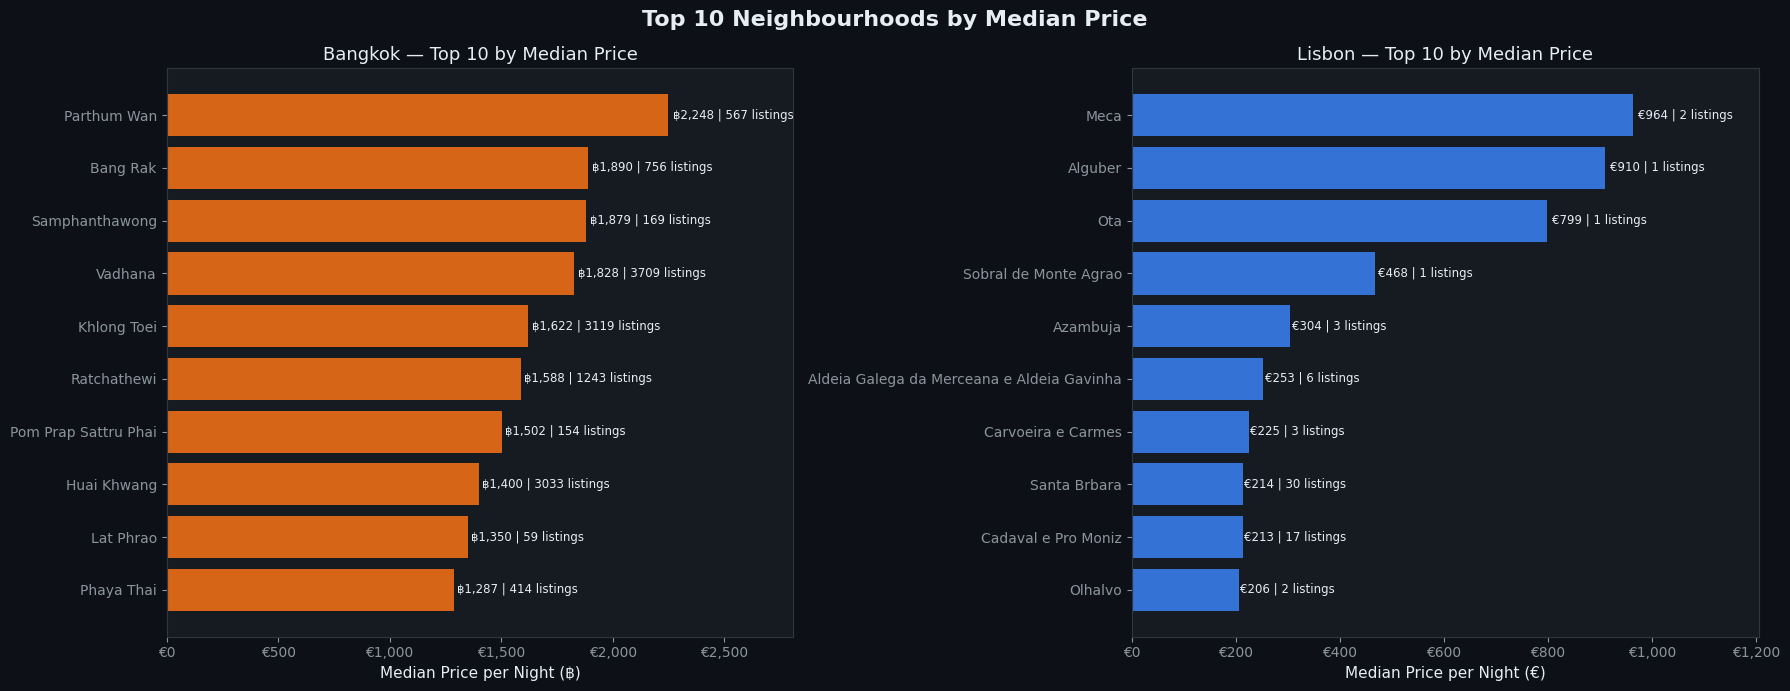

Chart 5 saved.


In [14]:
#Top 10 Neighbourhoods by Median Price

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Top 10 Neighbourhoods by Median Price", 
             fontsize=16, fontweight="bold")

for ax, df, city, color, currency in zip(
    axes,
    [bkk, lis],
    ["Bangkok", "Lisbon"],
    [COLORS["bangkok"], COLORS["lisbon"]],
    ["฿", "€"]
):
    top10 = (
        df[df["price"].notna()]
        .groupby("neighbourhood_cleansed")
        .agg(
            median_price=("price", "median"),
            listing_count=("listing_id", "count"),
            avg_occupancy=("occupancy_rate", "mean")
        )
        .reset_index()
        .nlargest(10, "median_price")
        .sort_values("median_price", ascending=True)
    )

    bars = ax.barh(top10["neighbourhood_cleansed"], top10["median_price"],
                   color=color, alpha=0.85, edgecolor="none")
    
    for bar, (_, row) in zip(bars, top10.iterrows()):
        ax.text(bar.get_width() + bar.get_width() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{currency}{row['median_price']:,.0f} | {row['listing_count']} listings",
                va="center", fontsize=8.5, color="#e6edf3")

    ax.set_title(f"{city} — Top 10 by Median Price")
    ax.set_xlabel(f"Median Price per Night ({currency})")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{currency}{x:,.0f}"))
    ax.margins(x=0.25)

plt.tight_layout()
plt.savefig("05_neighbourhood_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved.")

In [16]:

# Bangkok Neighbourhood Map

import os

PROJECT_ROOT = r"C:\Users\Isuru\Desktop\Airbnb-Market-Analytics-System"

os.chdir(PROJECT_ROOT)

print(os.getcwd())

import folium
from folium.features import GeoJsonTooltip
from branca.colormap import LinearColormap

# Load Bangkok neighbourhood stats 
bkk_neighbourhood_stats = query("""
    SELECT 
        neighbourhood_cleansed,
        COUNT(*) as listing_count,
        ROUND(AVG(price)::numeric, 0) as avg_price,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price)::numeric, 0) as median_price,
        ROUND(AVG(review_scores_rating)::numeric, 3) as avg_rating,
        ROUND(AVG(occupancy_rate)::numeric, 1) as avg_occupancy
    FROM fact_listings
    WHERE city = 'bangkok' AND price IS NOT NULL
    GROUP BY neighbourhood_cleansed
""")

with open(
    "data/processed/bangkok/neighbourhoods_clean.geojson",
    "r",
    encoding="utf-8"
) as f:
    bkk_geojson = json.load(f)

# Merge stats into GeoJSON properties
stats_dict = bkk_neighbourhood_stats.set_index("neighbourhood_cleansed").to_dict("index")

for feature in bkk_geojson["features"]:
    name = feature["properties"].get("neighbourhood", "")
    if name in stats_dict:
        feature["properties"].update(stats_dict[name])
    else:
        feature["properties"].update({
            "listing_count": 0, "avg_price": 0,
            "median_price": 0, "avg_rating": None, "avg_occupancy": None
        })

# Build colormap 
prices = bkk_neighbourhood_stats["median_price"].dropna()
colormap = LinearColormap(
    colors=["#1e3a5f", "#1d4ed8", "#f97316", "#ef4444"],
    vmin=prices.quantile(0.05),
    vmax=prices.quantile(0.95),
    caption="Median Price per Night (฿ THB)"
)

# Build map 
bkk_map = folium.Map(
    location=[13.75, 100.57],
    zoom_start=11,
    tiles="CartoDB dark_matter"
)

folium.GeoJson(
    bkk_geojson,
    name="Neighbourhoods",
    style_function=lambda feature: {
        "fillColor": colormap(feature["properties"].get("median_price", 0))
                     if feature["properties"].get("median_price", 0) > 0
                     else "#2d3748",
        "color": "#4a5568",
        "weight": 1.5,
        "fillOpacity": 0.75,
    },
    tooltip=GeoJsonTooltip(
        fields=["neighbourhood", "listing_count", "median_price", 
                "avg_rating", "avg_occupancy"],
        aliases=["Neighbourhood:", "Listings:", "Median Price (฿):", 
                 "Avg Rating:", "Avg Occupancy (%):"],
        localize=True,
        sticky=True,
        style="""
            background-color: #1a202c;
            color: #e2e8f0;
            font-family: monospace;
            font-size: 12px;
            border: 1px solid #4a5568;
            border-radius: 4px;
            padding: 8px;
        """
    )
).add_to(bkk_map)

colormap.add_to(bkk_map)

# Add title
title_html = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: rgba(13,17,23,0.9); padding: 10px 20px;
     border-radius: 8px; border: 1px solid #30363d;">
    <h4 style="color: #f97316; margin: 0; font-family: Arial;">
        🏙️ Bangkok Airbnb Market — Neighbourhood Price Map
    </h4>
    <p style="color: #8b949e; margin: 4px 0 0 0; font-size: 12px;">
        Hover over neighbourhoods for details | Colour = Median Price
    </p>
</div>
"""
bkk_map.get_root().html.add_child(folium.Element(title_html))

bkk_map.save("notebooks/chart06_bangkok_map.html")
print("Bangkok map saved to notebooks/chart06_bangkok_map.html")
print(f"Neighbourhoods mapped: {len(bkk_neighbourhood_stats)}")
print("\nTop 5 neighbourhoods by median price:")
print(bkk_neighbourhood_stats.nlargest(5, "median_price")[
    ["neighbourhood_cleansed", "median_price", "listing_count", "avg_occupancy"]
].to_string(index=False))
print("\nTop 5 neighbourhoods by listing count:")
print(bkk_neighbourhood_stats.nlargest(5, "listing_count")[
    ["neighbourhood_cleansed", "listing_count", "median_price", "avg_occupancy"]
].to_string(index=False))

C:\Users\Isuru\Desktop\Airbnb-Market-Analytics-System
Bangkok map saved to notebooks/chart06_bangkok_map.html
Neighbourhoods mapped: 50

Top 5 neighbourhoods by median price:
neighbourhood_cleansed  median_price  listing_count  avg_occupancy
           Parthum Wan        2248.0            567           30.7
              Bang Rak        1890.0            756           28.6
        Samphanthawong        1879.0            169           20.5
               Vadhana        1828.0           3709           29.4
           Khlong Toei        1622.0           3119           25.8

Top 5 neighbourhoods by listing count:
neighbourhood_cleansed  listing_count  median_price  avg_occupancy
               Vadhana           3709        1828.0           29.4
           Khlong Toei           3119        1622.0           25.8
           Huai Khwang           3033        1400.0           20.0
           Ratchathewi           1243        1588.0           28.7
                Sathon           1092        116

In [17]:
# Lisbon Neighbourhood Map


# Load Lisbon neighbourhood stats 
lis_neighbourhood_stats = query("""
    SELECT 
        neighbourhood_cleansed,
        COUNT(*) as listing_count,
        ROUND(AVG(price)::numeric, 0) as avg_price,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price)::numeric, 0) as median_price,
        ROUND(AVG(review_scores_rating)::numeric, 3) as avg_rating,
        ROUND(AVG(occupancy_rate)::numeric, 1) as avg_occupancy
    FROM fact_listings
    WHERE city = 'lisbon' AND price IS NOT NULL
    GROUP BY neighbourhood_cleansed
""")

# Load GeoJSON
with open("data/processed/lisbon/neighbourhoods_clean.geojson", "r", encoding="utf-8") as f:
    lis_geojson = json.load(f)

# Merge stats
lis_stats_dict = lis_neighbourhood_stats.set_index("neighbourhood_cleansed").to_dict("index")

for feature in lis_geojson["features"]:
    name = feature["properties"].get("neighbourhood", "")
    if name in lis_stats_dict:
        feature["properties"].update(lis_stats_dict[name])
    else:
        feature["properties"].update({
            "listing_count": 0, "avg_price": 0,
            "median_price": 0, "avg_rating": None, "avg_occupancy": None
        })

# Colormap 
lis_prices = lis_neighbourhood_stats["median_price"].dropna()
lis_colormap = LinearColormap(
    colors=["#1e3a5f", "#1d4ed8", "#3b82f6", "#60a5fa"],
    vmin=lis_prices.quantile(0.05),
    vmax=lis_prices.quantile(0.95),
    caption="Median Price per Night (€ EUR)"
)

# Build map
lis_map = folium.Map(
    location=[38.72, -9.14],
    zoom_start=11,
    tiles="CartoDB dark_matter"
)

folium.GeoJson(
    lis_geojson,
    name="Neighbourhoods",
    style_function=lambda feature: {
        "fillColor": lis_colormap(feature["properties"].get("median_price", 0))
                     if feature["properties"].get("median_price", 0) > 0
                     else "#2d3748",
        "color": "#4a5568",
        "weight": 1.5,
        "fillOpacity": 0.75,
    },
    tooltip=GeoJsonTooltip(
        fields=["neighbourhood", "listing_count", "median_price",
                "avg_rating", "avg_occupancy"],
        aliases=["Neighbourhood:", "Listings:", "Median Price (€):",
                 "Avg Rating:", "Avg Occupancy (%):"],
        localize=True,
        sticky=True,
        style="""
            background-color: #1a202c;
            color: #e2e8f0;
            font-family: monospace;
            font-size: 12px;
            border: 1px solid #4a5568;
            border-radius: 4px;
            padding: 8px;
        """
    )
).add_to(lis_map)

lis_colormap.add_to(lis_map)

title_html = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: rgba(13,17,23,0.9); padding: 10px 20px;
     border-radius: 8px; border: 1px solid #30363d;">
    <h4 style="color: #3b82f6; margin: 0; font-family: Arial;">
        🏛️ Lisbon Airbnb Market — Neighbourhood Price Map
    </h4>
    <p style="color: #8b949e; margin: 4px 0 0 0; font-size: 12px;">
        Hover over neighbourhoods for details | Colour = Median Price
    </p>
</div>
"""
lis_map.get_root().html.add_child(folium.Element(title_html))

lis_map.save("notebooks/chart07_lisbon_map.html")
print("Lisbon map saved to notebooks/chart07_lisbon_map.html")
print(f"Neighbourhoods mapped: {len(lis_neighbourhood_stats)}")
print("\nTop 5 neighbourhoods by median price:")
print(lis_neighbourhood_stats.nlargest(5, "median_price")[
    ["neighbourhood_cleansed", "median_price", "listing_count", "avg_occupancy"]
].to_string(index=False))
print("\nTop 5 neighbourhoods by listing count:")
print(lis_neighbourhood_stats.nlargest(5, "listing_count")[
    ["neighbourhood_cleansed", "listing_count", "median_price", "avg_occupancy"]
].to_string(index=False))

Lisbon map saved to notebooks/chart07_lisbon_map.html
Neighbourhoods mapped: 126

Top 5 neighbourhoods by median price:
neighbourhood_cleansed  median_price  listing_count  avg_occupancy
                  Meca         964.0              2           14.2
               Alguber         910.0              1           11.2
                   Ota         799.0              1           19.2
 Sobral de Monte Agrao         468.0              1           26.0
              Azambuja         304.0              3           14.2

Top 5 neighbourhoods by listing count:
neighbourhood_cleansed  listing_count  median_price  avg_occupancy
     Santa Maria Maior           3237         158.0           32.3
           Misericrdia           2325         156.0           34.8
               Arroios           1838         108.0           35.5
     Cascais e Estoril           1439         157.0           36.7
          Santo Antnio           1271         152.0           34.0


Coordinates loaded: 44,739 listings

Bangkok — Price by Distance from Centre:
distance_bin  median_price  listing_count  avg_occupancy
         0-2        1130.5           1184      16.142534
         2-4        1400.0           1607      24.802545
         4-6        1519.0           4008      26.823500
         6-8        1602.0           5476      26.924951
        8-10        1443.0           4743      22.717599
       10-15        1100.0           4191      22.866869
       15-20        1013.0           1399      16.858134
         20+        1080.0            665      17.995158

Lisbon — Price by Distance from Centre:
distance_bin  median_price  listing_count  avg_occupancy
         0-2       142.500          10907      34.173504
         2-4       107.535           2338      38.897425
         4-6       114.500            913      34.251347
         6-8       105.080            778      33.159126
        8-10        93.330            447      31.838837
       10-15       101.910

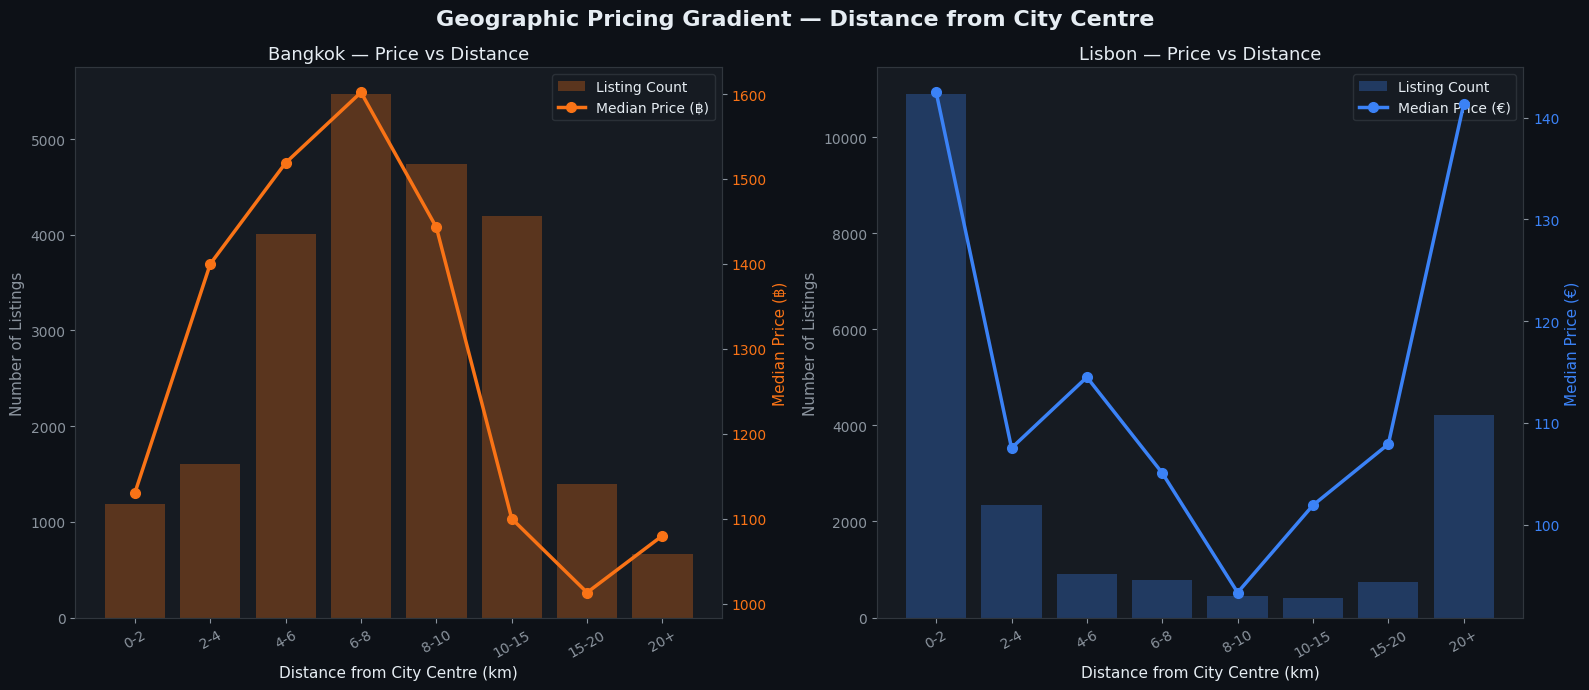


Chart 8 saved.


In [20]:

# CHART 8: Geographic Pricing Gradient — Distance from City Centre


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Geographic Pricing Gradient — Distance from City Centre",
             fontsize=16, fontweight="bold")

CITY_CENTRES = {
    "bangkok": (13.7563, 100.5018),
    "lisbon":  (38.7169, -9.1399),
}

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Load coordinates directly from enriched CSVs
bkk_coords = pd.read_csv("data/processed/bangkok/listings_enriched.csv",
                          usecols=["id", "latitude", "longitude", "price", 
                                   "occupancy_rate", "room_type"])[
                          ["id", "latitude", "longitude", "price", 
                           "occupancy_rate", "room_type"]].dropna()
bkk_coords["city"] = "bangkok"
bkk_coords = bkk_coords.rename(columns={"id": "listing_id"})

lis_coords = pd.read_csv("data/processed/lisbon/listings_enriched.csv",
                          usecols=["id", "latitude", "longitude", "price",
                                   "occupancy_rate", "room_type"])[
                          ["id", "latitude", "longitude", "price",
                           "occupancy_rate", "room_type"]].dropna()
lis_coords["city"] = "lisbon"
lis_coords = lis_coords.rename(columns={"id": "listing_id"})

listing_coords = pd.concat([bkk_coords, lis_coords], ignore_index=True)
print(f"Coordinates loaded: {len(listing_coords):,} listings")

for ax, city, color, currency, centre in zip(
    axes,
    ["bangkok", "lisbon"],
    [COLORS["bangkok"], COLORS["lisbon"]],
    ["฿", "€"],
    [CITY_CENTRES["bangkok"], CITY_CENTRES["lisbon"]]
):
    city_data = listing_coords[listing_coords["city"] == city].copy()

    city_data["distance_km"] = city_data.apply(
        lambda row: haversine_distance(
            row["latitude"], row["longitude"],
            centre[0], centre[1]
        ), axis=1
    )

    city_data["distance_bin"] = pd.cut(
        city_data["distance_km"],
        bins=[0, 2, 4, 6, 8, 10, 15, 20, 50],
        labels=["0-2", "2-4", "4-6", "6-8", "8-10", "10-15", "15-20", "20+"]
    )

    dist_stats = city_data.groupby("distance_bin", observed=True).agg(
        median_price=("price", "median"),
        listing_count=("listing_id", "count"),
        avg_occupancy=("occupancy_rate", "mean")
    ).reset_index()

    ax2 = ax.twinx()
    ax.bar(range(len(dist_stats)), dist_stats["listing_count"],
           color=color, alpha=0.3, label="Listing Count")
    ax2.plot(range(len(dist_stats)), dist_stats["median_price"],
             color=color, linewidth=2.5, marker="o",
             markersize=7, label=f"Median Price ({currency})", zorder=5)

    ax.set_xticks(range(len(dist_stats)))
    ax.set_xticklabels(dist_stats["distance_bin"], rotation=30)
    ax.set_xlabel("Distance from City Centre (km)")
    ax.set_ylabel("Number of Listings", color="#8b949e")
    ax2.set_ylabel(f"Median Price ({currency})", color=color)
    ax2.tick_params(axis="y", labelcolor=color)
    ax.set_title(f"{city.capitalize()} — Price vs Distance")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    print(f"\n{city.capitalize()} — Price by Distance from Centre:")
    print(dist_stats.to_string(index=False))

plt.tight_layout()
plt.savefig("notebooks/chart08_price_gradient.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 8 saved.")

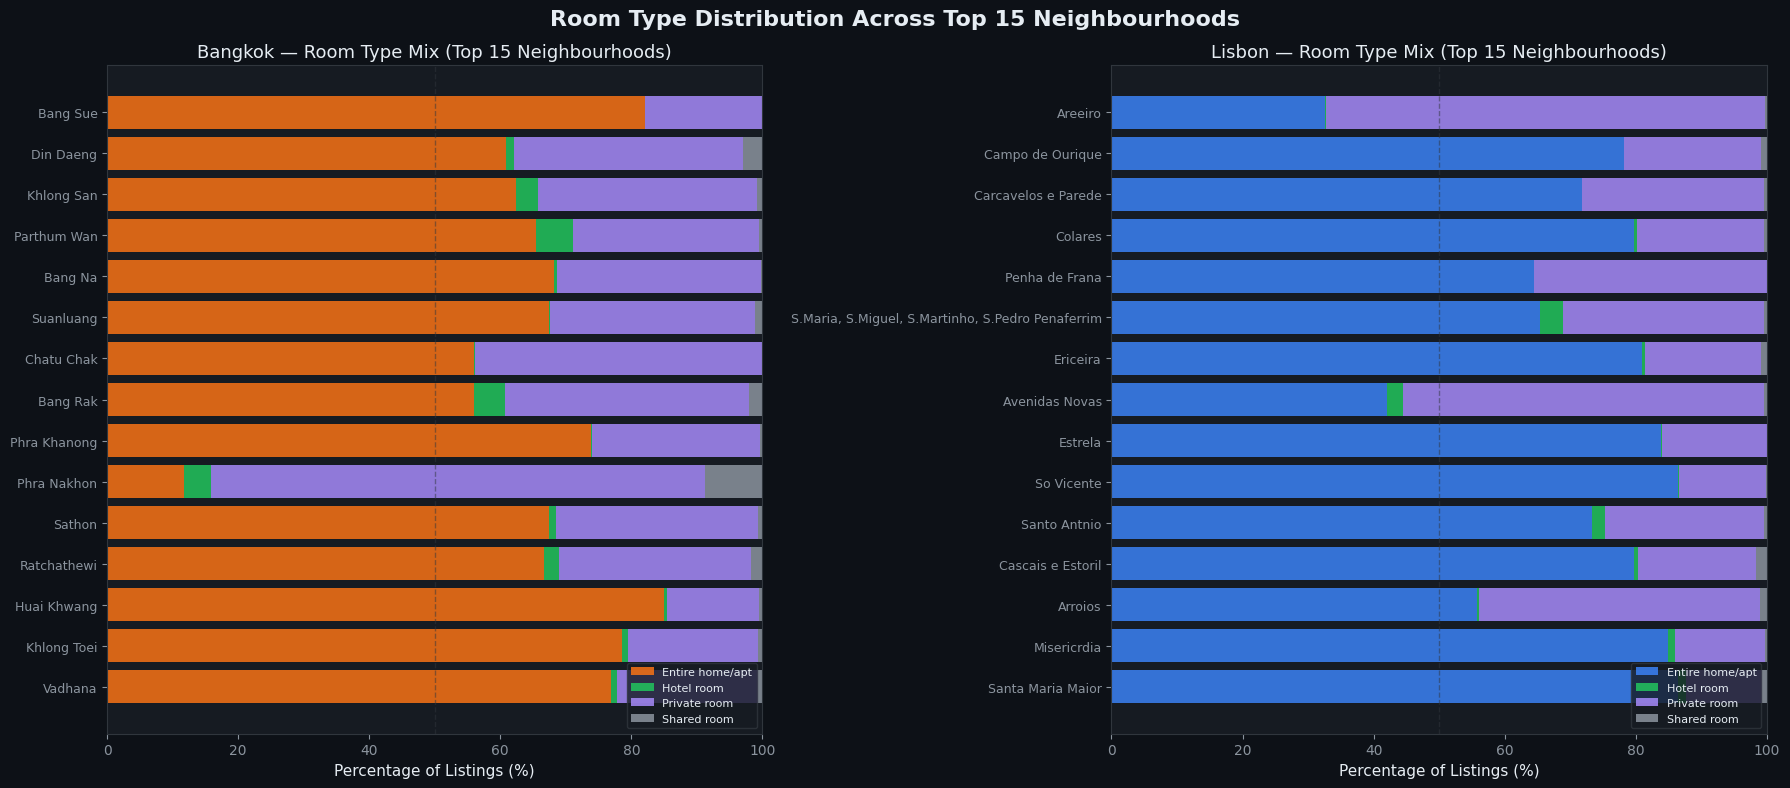

Chart 9 saved.


In [21]:
# =============================================================================
# CHART 9: Room Type Distribution by Neighbourhood (Top 15)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Room Type Distribution Across Top 15 Neighbourhoods",
             fontsize=16, fontweight="bold")

for ax, df, city, currency in zip(
    axes,
    [bkk, lis],
    ["Bangkok", "Lisbon"],
    ["฿", "€"]
):
    # Top 15 neighbourhoods by listing count
    top15 = (df.groupby("neighbourhood_cleansed")["listing_id"]
               .count()
               .nlargest(15)
               .index.tolist())

    df_top = df[df["neighbourhood_cleansed"].isin(top15)].copy()

    pivot = (df_top.groupby(["neighbourhood_cleansed", "room_type"])
                   .size()
                   .unstack(fill_value=0))

    # Normalize to percentages
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct = pivot_pct.loc[
        df_top.groupby("neighbourhood_cleansed").size()
              .nlargest(15).index
    ]

    room_colors = {
        "Entire home/apt": COLORS["bangkok"] if city == "Bangkok" else COLORS["lisbon"],
        "Private room":    "#a78bfa",
        "Hotel room":      "#22c55e",
        "Shared room":     "#8b949e"
    }

    bottom = np.zeros(len(pivot_pct))
    for room_type in pivot_pct.columns:
        color = room_colors.get(room_type, "#8b949e")
        ax.barh(range(len(pivot_pct)), pivot_pct[room_type],
                left=bottom, color=color, alpha=0.85,
                label=room_type, edgecolor="none")
        bottom += pivot_pct[room_type].values

    ax.set_yticks(range(len(pivot_pct)))
    ax.set_yticklabels(pivot_pct.index, fontsize=9)
    ax.set_xlabel("Percentage of Listings (%)")
    ax.set_title(f"{city} — Room Type Mix (Top 15 Neighbourhoods)")
    ax.set_xlim(0, 100)
    ax.legend(loc="lower right", fontsize=8)
    ax.axvline(50, color="#30363d", linewidth=1, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("notebooks/chart09_room_type_geography.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved.")


Bangkok — Review Volume by Year:
 review_year  review_count
        2015          7046
        2016         14810
        2017         26025
        2018         40300
        2019         59005
        2020         18013
        2021          5171
        2022         40559
        2023         97171
        2024        148848
        2025        122900

Lisbon — Review Volume by Year:
 review_year  review_count
        2015         29846
        2016         54163
        2017         92394
        2018        128059
        2019        167540
        2020         52390
        2021         85155
        2022        224729
        2023        272754
        2024        311253
        2025        341367
        2026         53627


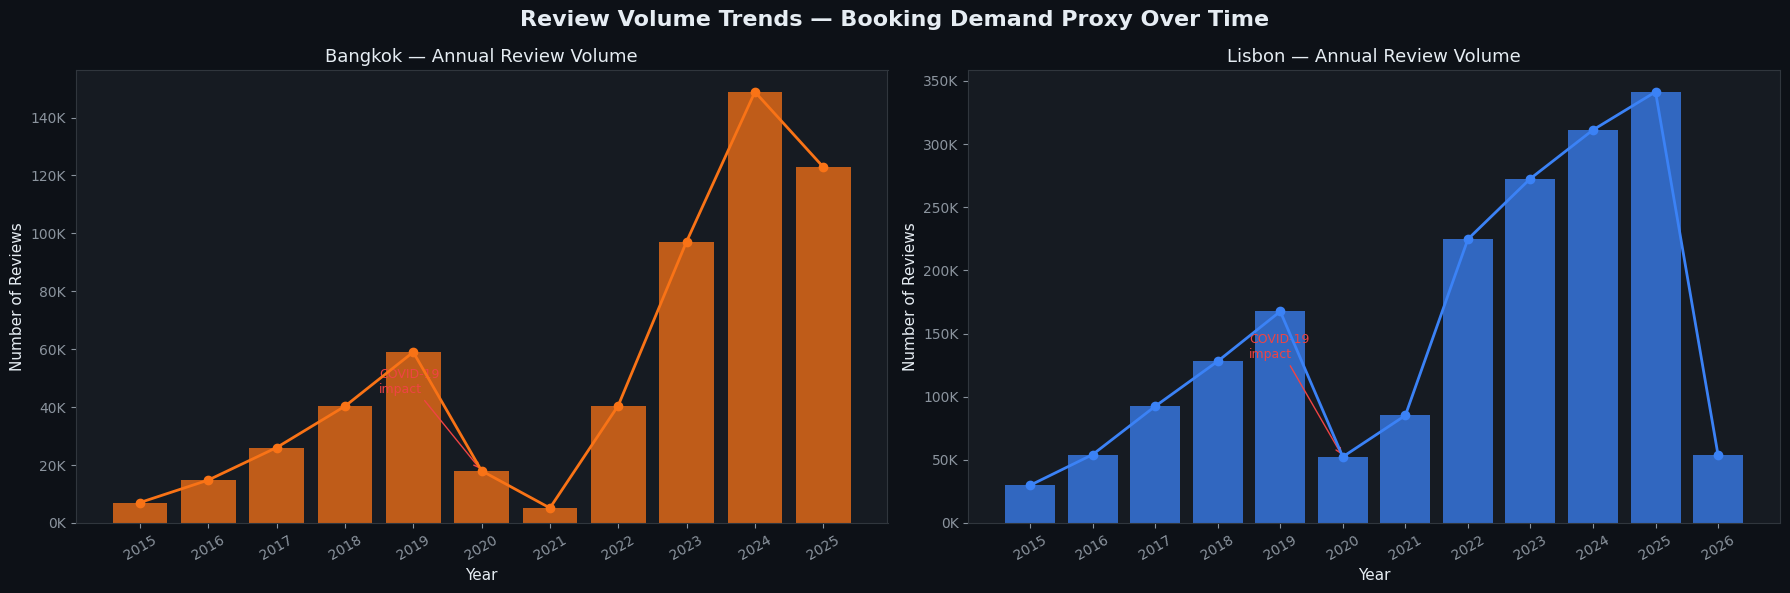


Chart 10 saved.


In [22]:
# CHART 10: Review Volume Trend by Year — Bangkok vs Lisbon

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Review Volume Trends — Booking Demand Proxy Over Time",
             fontsize=16, fontweight="bold")

for ax, city, color, df_city in zip(
    axes,
    ["Bangkok", "Lisbon"],
    [COLORS["bangkok"], COLORS["lisbon"]],
    ["bangkok", "lisbon"]
):
    yearly = (reviews[reviews["city"] == df_city]
              .groupby("review_year")
              .size()
              .reset_index(name="review_count"))
    yearly = yearly[(yearly["review_year"] >= 2015) & 
                    (yearly["review_year"] <= 2026)]

    bars = ax.bar(yearly["review_year"], yearly["review_count"],
                  color=color, alpha=0.75, edgecolor="none")
    ax.plot(yearly["review_year"], yearly["review_count"],
            color=color, linewidth=2, marker="o", markersize=6, zorder=5)

    # Annotate COVID dip
    if 2020 in yearly["review_year"].values:
        covid_val = yearly[yearly["review_year"] == 2020]["review_count"].values[0]
        ax.annotate("COVID-19\nimpact",
                    xy=(2020, covid_val),
                    xytext=(2018.5, covid_val * 2.5),
                    arrowprops=dict(arrowstyle="->", color="#ef4444"),
                    color="#ef4444", fontsize=9)

    ax.set_title(f"{city} — Annual Review Volume")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Reviews")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
    ax.set_xticks(yearly["review_year"])
    ax.tick_params(axis="x", rotation=30)

    print(f"\n{city} — Review Volume by Year:")
    print(yearly.to_string(index=False))

plt.tight_layout()
plt.savefig("notebooks/chart10_review_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 10 saved.")


Weekend vs Weekday Availability:
Bangkok  — Weekday: 68.7%  Weekend: 68.1%
Lisbon   — Weekday: 59.0%  Weekend: 58.4%


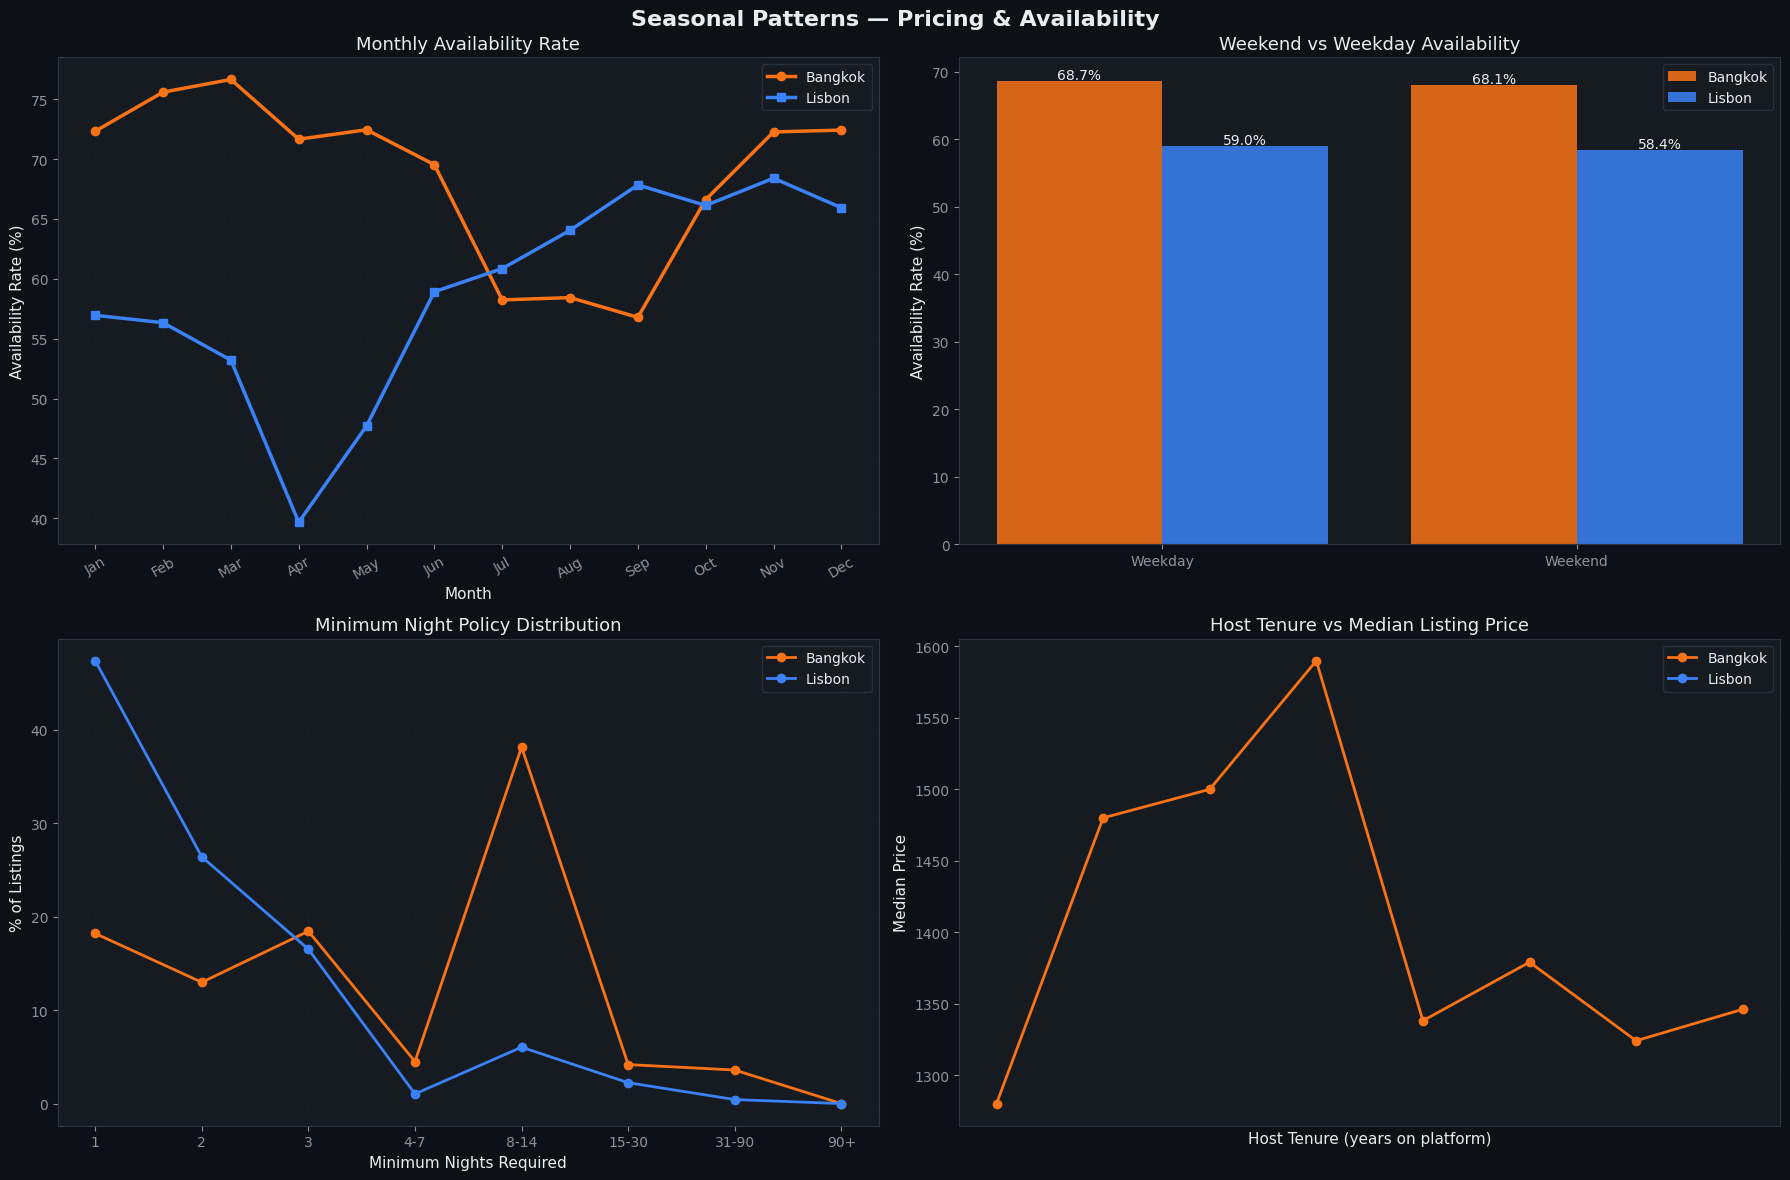

Chart 11 saved.


In [23]:
# 11 Pricing & Availability by Month


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Seasonal Patterns — Pricing & Availability",
             fontsize=16, fontweight="bold")

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# Monthly calendar availability 
bkk_cal = calendar[calendar["city"] == "bangkok"]
lis_cal  = calendar[calendar["city"] == "lisbon"]

bkk_monthly_avail = bkk_cal.groupby("month")["available"].mean() * 100
lis_monthly_avail = lis_cal.groupby("month")["available"].mean() * 100

ax1 = axes[0, 0]
ax1.plot(range(1,13), bkk_monthly_avail.reindex(range(1,13)),
         color=COLORS["bangkok"], linewidth=2.5, marker="o",
         markersize=6, label="Bangkok")
ax1.plot(range(1,13), lis_monthly_avail.reindex(range(1,13)),
         color=COLORS["lisbon"], linewidth=2.5, marker="s",
         markersize=6, label="Lisbon")
ax1.set_title("Monthly Availability Rate")
ax1.set_xlabel("Month")
ax1.set_ylabel("Availability Rate (%)")
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_names, rotation=30)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Weekend vs weekday availability 
ax2 = axes[0, 1]
bkk_weekend = bkk_cal.groupby("is_weekend")["available"].mean() * 100
lis_weekend  = lis_cal.groupby("is_weekend")["available"].mean() * 100

labels = ["Weekday", "Weekend"]
bkk_vals = [bkk_weekend.get(False, 0), bkk_weekend.get(True, 0)]
lis_vals  = [lis_weekend.get(False, 0), lis_weekend.get(True, 0)]
x = np.arange(2)
ax2.bar(x - 0.2, bkk_vals, 0.4, color=COLORS["bangkok"],
        alpha=0.85, label="Bangkok")
ax2.bar(x + 0.2, lis_vals, 0.4, color=COLORS["lisbon"],
        alpha=0.85, label="Lisbon")
ax2.set_title("Weekend vs Weekday Availability")
ax2.set_ylabel("Availability Rate (%)")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
for i, (b, l) in enumerate(zip(bkk_vals, lis_vals)):
    ax2.text(i - 0.2, b + 0.3, f"{b:.1f}%", ha="center", fontsize=10)
    ax2.text(i + 0.2, l + 0.3, f"{l:.1f}%", ha="center", fontsize=10)

print("\nWeekend vs Weekday Availability:")
print(f"Bangkok  — Weekday: {bkk_vals[0]:.1f}%  Weekend: {bkk_vals[1]:.1f}%")
print(f"Lisbon   — Weekday: {lis_vals[0]:.1f}%  Weekend: {lis_vals[1]:.1f}%")

# Minimum nights distribution 
ax3 = axes[1, 0]
min_night_bins = [1, 2, 3, 7, 14, 30, 90, 365, 9999]
min_night_labels = ["1", "2", "3", "4-7", "8-14", "15-30", "31-90", "90+"]

for df, city, color in [(bkk, "Bangkok", COLORS["bangkok"]),
                         (lis, "Lisbon",  COLORS["lisbon"])]:
    df_mn = df["minimum_nights"].dropna()
    df_mn = df_mn[df_mn <= 365]
    counts = pd.cut(df_mn, bins=min_night_bins,
                    labels=min_night_labels, right=True).value_counts().sort_index()
    pct = counts / counts.sum() * 100
    ax3.plot(range(len(pct)), pct.values, marker="o",
             linewidth=2, label=city, color=color)

ax3.set_xticks(range(len(min_night_labels)))
ax3.set_xticklabels(min_night_labels)
ax3.set_title("Minimum Night Policy Distribution")
ax3.set_xlabel("Minimum Nights Required")
ax3.set_ylabel("% of Listings")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Host tenure vs median price
ax4 = axes[1, 1]
for df, city, color in [(bkk, "Bangkok", COLORS["bangkok"]),
                         (lis, "Lisbon",  COLORS["lisbon"])]:
    df_t = df[df["host_tenure_years"].notna() & 
              df["price"].notna() &
              (df["host_tenure_years"] <= 16)].copy()
    df_t["tenure_bin"] = pd.cut(df_t["host_tenure_years"],
                                 bins=[0,1,2,3,4,5,7,10,16],
                                 labels=["<1","1-2","2-3","3-4",
                                         "4-5","5-7","7-10","10+"])
    tenure_price = df_t.groupby("tenure_bin", observed=True)["price"].median()
    ax4.plot(range(len(tenure_price)), tenure_price.values,
             marker="o", linewidth=2, label=city, color=color)
    ax4.set_xticks(range(len(tenure_price)))
    ax4.set_xticklabels(tenure_price.index)

ax4.set_title("Host Tenure vs Median Listing Price")
ax4.set_xlabel("Host Tenure (years on platform)")
ax4.set_ylabel("Median Price")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/chart11_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 11 saved.")


Bangkok Superhost Analysis:
  City: Bangkok
  Superhost %: 29.3%
  SH Median Price: 1390.0
  NSH Median Price: 1371.0
  SH Avg Occupancy: 32.01648401253918
  NSH Avg Occupancy: 31.701531658082306
  SH Avg Rating: 4.857829412613653
  NSH Avg Rating: 4.574524667931689

Lisbon Superhost Analysis:
  City: Lisbon
  Superhost %: 32.3%
  SH Median Price: 144.0
  NSH Median Price: 125.0
  SH Avg Occupancy: 39.7062836914669
  NSH Avg Occupancy: 41.82770809848709
  SH Avg Rating: 4.830134907251265
  NSH Avg Rating: 4.552514219886242


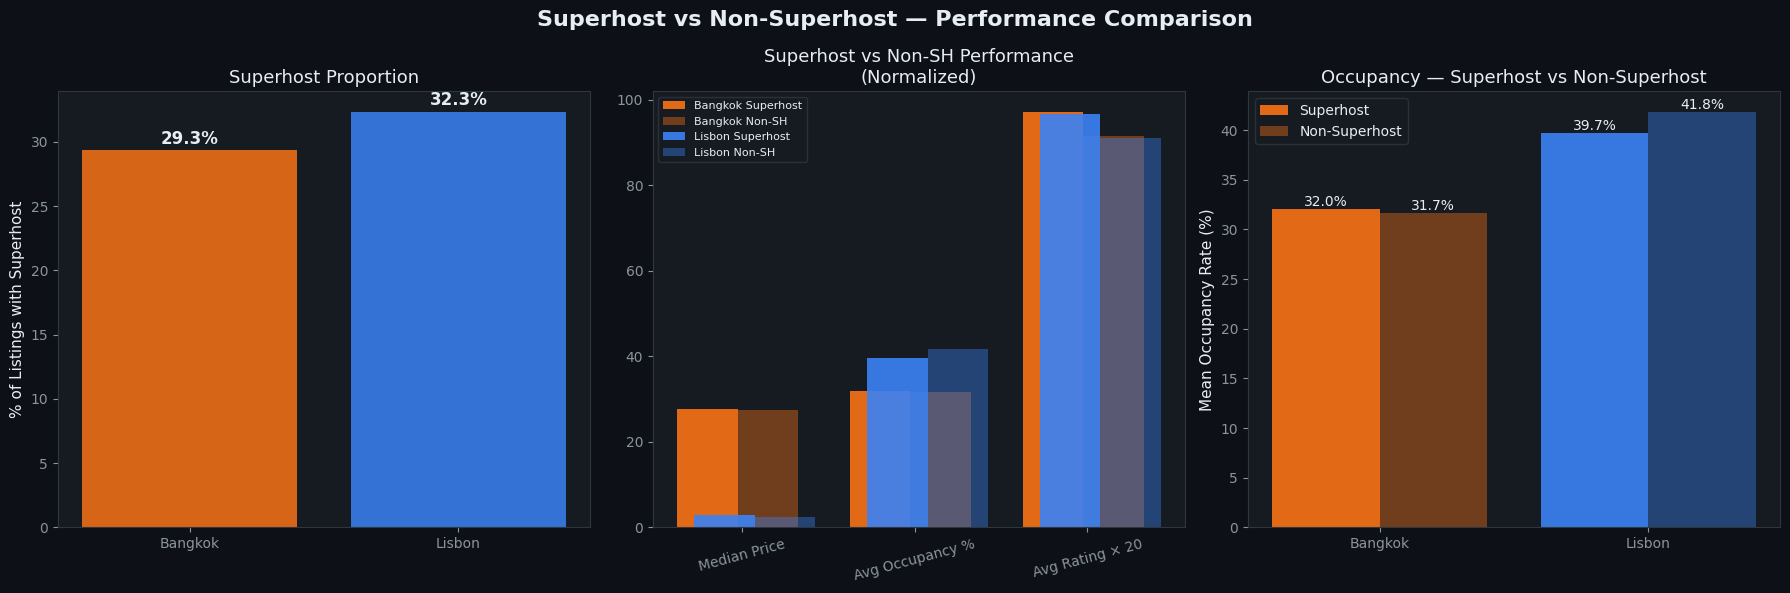


Chart 12 saved.


In [24]:

# 12 Superhost vs Non-Superhost Analysis


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Superhost vs Non-Superhost — Performance Comparison",
             fontsize=16, fontweight="bold")

metrics = {
    "Avg Price":       "price",
    "Avg Occupancy":   "occupancy_rate",
    "Avg Rating":      "review_scores_rating",
    "Avg Reviews/mo":  "reviews_per_month",
}

superhost_summary = []

for city, color, df_city in [("Bangkok", COLORS["bangkok"], bkk),
                               ("Lisbon",  COLORS["lisbon"],  lis)]:
    sh  = df_city[df_city["host_is_superhost"] == True]
    nsh = df_city[df_city["host_is_superhost"] == False]

    sh_pct  = len(sh)  / (len(sh) + len(nsh)) * 100
    nsh_pct = len(nsh) / (len(sh) + len(nsh)) * 100

    row = {"City": city,
           "Superhost %": f"{sh_pct:.1f}%",
           "SH Median Price": df_city[df_city["host_is_superhost"]==True]["price"].median(),
           "NSH Median Price": df_city[df_city["host_is_superhost"]==False]["price"].median(),
           "SH Avg Occupancy": sh["occupancy_rate"].mean(),
           "NSH Avg Occupancy": nsh["occupancy_rate"].mean(),
           "SH Avg Rating": sh["review_scores_rating"].mean(),
           "NSH Avg Rating": nsh["review_scores_rating"].mean()}
    superhost_summary.append(row)
    print(f"\n{city} Superhost Analysis:")
    for k, v in row.items():
        print(f"  {k}: {v}")

# Chart: Superhost % by city
ax1 = axes[0]
cities_list = ["Bangkok", "Lisbon"]
sh_pcts = [
    (bkk["host_is_superhost"] == True).sum() / bkk["host_is_superhost"].notna().sum() * 100,
    (lis["host_is_superhost"] == True).sum() / lis["host_is_superhost"].notna().sum() * 100
]
bars = ax1.bar(cities_list, sh_pcts, color=PALETTE_BOTH, alpha=0.85)
for bar, val in zip(bars, sh_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax1.set_title("Superhost Proportion")
ax1.set_ylabel("% of Listings with Superhost")

# Chart: Price comparison
ax2 = axes[1]
metric_labels = ["Median Price", "Avg Occupancy %", "Avg Rating × 20"]
for i, (city, color, df_city) in enumerate([
    ("Bangkok", COLORS["bangkok"], bkk),
    ("Lisbon",  COLORS["lisbon"],  lis)
]):
    sh  = df_city[df_city["host_is_superhost"] == True]
    nsh = df_city[df_city["host_is_superhost"] == False]

    # Normalize for display: price scaled down
    sh_norm  = [sh["price"].median() / 50,
                sh["occupancy_rate"].mean(),
                sh["review_scores_rating"].mean() * 20]
    nsh_norm = [nsh["price"].median() / 50,
                nsh["occupancy_rate"].mean(),
                nsh["review_scores_rating"].mean() * 20]

    x = np.arange(len(metric_labels)) + i * 0.1
    ax2.bar(x - 0.2, sh_norm,  0.35, color=color, alpha=0.9,
            label=f"{city} Superhost", hatch="")
    ax2.bar(x + 0.15, nsh_norm, 0.35, color=color, alpha=0.4,
            label=f"{city} Non-SH")

ax2.set_xticks(np.arange(len(metric_labels)))
ax2.set_xticklabels(metric_labels, rotation=15)
ax2.set_title("Superhost vs Non-SH Performance\n(Normalized)")
ax2.legend(fontsize=8)

# Chart: Occupancy comparison
ax3 = axes[2]
sh_occ  = [bkk[bkk["host_is_superhost"]==True]["occupancy_rate"].mean(),
            lis[lis["host_is_superhost"]==True]["occupancy_rate"].mean()]
nsh_occ = [bkk[bkk["host_is_superhost"]==False]["occupancy_rate"].mean(),
            lis[lis["host_is_superhost"]==False]["occupancy_rate"].mean()]

x = np.arange(2)
ax3.bar(x - 0.2, sh_occ,  0.4, color=PALETTE_BOTH, alpha=0.9,
        label="Superhost")
ax3.bar(x + 0.2, nsh_occ, 0.4, color=PALETTE_BOTH, alpha=0.4,
        label="Non-Superhost")
for i in range(2):
    ax3.text(i - 0.2, sh_occ[i]  + 0.3, f"{sh_occ[i]:.1f}%",
             ha="center", fontsize=10)
    ax3.text(i + 0.2, nsh_occ[i] + 0.3, f"{nsh_occ[i]:.1f}%",
             ha="center", fontsize=10)
ax3.set_xticks(x)
ax3.set_xticklabels(["Bangkok", "Lisbon"])
ax3.set_ylabel("Mean Occupancy Rate (%)")
ax3.set_title("Occupancy — Superhost vs Non-Superhost")
ax3.legend()

plt.tight_layout()
plt.savefig("notebooks/chart12_superhost.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 12 saved.")


Bangkok — Commercial vs Casual Hosts:
  Commercial hosts (>1 listing): 23,241 listings (80.7%)
  Casual hosts (1 listing):      5,565 listings (19.3%)
  Commercial median price:        1375
  Casual median price:            1423
  Commercial avg occupancy:       27.5%
  Casual avg occupancy:           48.2%
  Commercial avg rating:          4.684
  Casual avg rating:              4.723

Lisbon — Commercial vs Casual Hosts:
  Commercial hosts (>1 listing): 18,526 listings (74.3%)
  Casual hosts (1 listing):      6,424 listings (25.7%)
  Commercial median price:        128
  Casual median price:            143
  Commercial avg occupancy:       39.5%
  Casual avg occupancy:           45.8%
  Commercial avg rating:          4.621
  Casual avg rating:              4.741


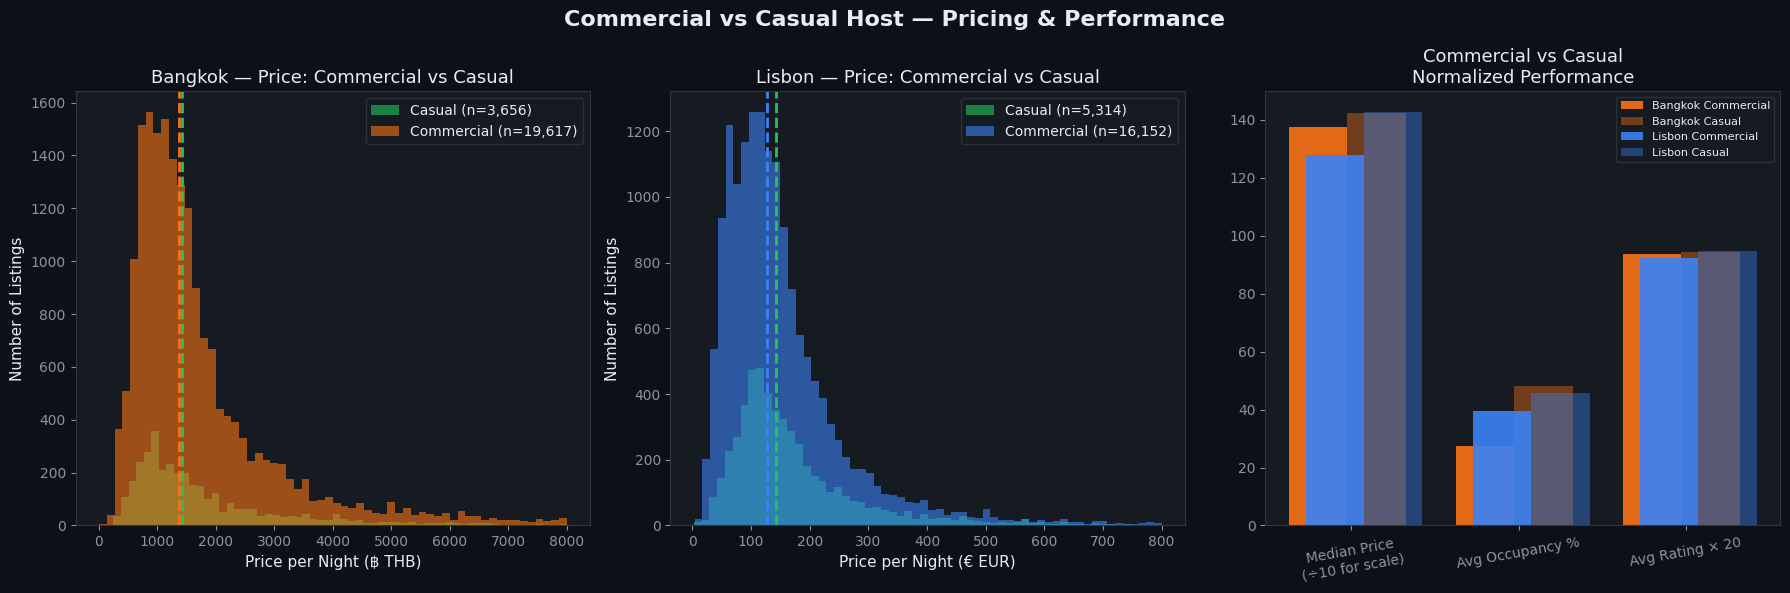


Chart 13 saved.


In [25]:

# CHART 13: Commercial vs Casual Host Comparison


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Commercial vs Casual Host — Pricing & Performance",
             fontsize=16, fontweight="bold")

for i, (city, color, df_city) in enumerate([
    ("Bangkok", COLORS["bangkok"], bkk),
    ("Lisbon",  COLORS["lisbon"],  lis)
]):
    comm   = df_city[df_city["is_commercial_host"] == True]
    casual = df_city[df_city["is_commercial_host"] == False]

    print(f"\n{city} — Commercial vs Casual Hosts:")
    print(f"  Commercial hosts (>1 listing): {len(comm):,} listings "
          f"({len(comm)/len(df_city)*100:.1f}%)")
    print(f"  Casual hosts (1 listing):      {len(casual):,} listings "
          f"({len(casual)/len(df_city)*100:.1f}%)")
    print(f"  Commercial median price:        {df_city[df_city['is_commercial_host']==True]['price'].median():.0f}")
    print(f"  Casual median price:            {df_city[df_city['is_commercial_host']==False]['price'].median():.0f}")
    print(f"  Commercial avg occupancy:       {comm['occupancy_rate'].mean():.1f}%")
    print(f"  Casual avg occupancy:           {casual['occupancy_rate'].mean():.1f}%")
    print(f"  Commercial avg rating:          {comm['review_scores_rating'].mean():.3f}")
    print(f"  Casual avg rating:              {casual['review_scores_rating'].mean():.3f}")

# Price distribution: commercial vs casual — Bangkok
ax1 = axes[0]
bkk_comm_price   = bkk[bkk["is_commercial_host"]==True]["price"].dropna()
bkk_casual_price = bkk[bkk["is_commercial_host"]==False]["price"].dropna()
bkk_comm_cap   = bkk_comm_price[bkk_comm_price <= 8000]
bkk_casual_cap = bkk_casual_price[bkk_casual_price <= 8000]

ax1.hist(bkk_casual_cap, bins=60, color=COLORS["positive"],
         alpha=0.6, label=f"Casual (n={len(bkk_casual_price):,})",
         edgecolor="none")
ax1.hist(bkk_comm_cap, bins=60, color=COLORS["bangkok"],
         alpha=0.6, label=f"Commercial (n={len(bkk_comm_price):,})",
         edgecolor="none")
ax1.axvline(bkk_casual_price.median(), color=COLORS["positive"],
            linewidth=2, linestyle="--")
ax1.axvline(bkk_comm_price.median(), color=COLORS["bangkok"],
            linewidth=2, linestyle="--")
ax1.set_title("Bangkok — Price: Commercial vs Casual")
ax1.set_xlabel("Price per Night (฿ THB)")
ax1.set_ylabel("Number of Listings")
ax1.legend()

# Price distribution: Lisbon
ax2 = axes[1]
lis_comm_price   = lis[lis["is_commercial_host"]==True]["price"].dropna()
lis_casual_price = lis[lis["is_commercial_host"]==False]["price"].dropna()
lis_comm_cap   = lis_comm_price[lis_comm_price <= 800]
lis_casual_cap = lis_casual_price[lis_casual_price <= 800]

ax2.hist(lis_casual_cap, bins=60, color=COLORS["positive"],
         alpha=0.6, label=f"Casual (n={len(lis_casual_price):,})",
         edgecolor="none")
ax2.hist(lis_comm_cap, bins=60, color=COLORS["lisbon"],
         alpha=0.6, label=f"Commercial (n={len(lis_comm_price):,})",
         edgecolor="none")
ax2.axvline(lis_casual_price.median(), color=COLORS["positive"],
            linewidth=2, linestyle="--")
ax2.axvline(lis_comm_price.median(), color=COLORS["lisbon"],
            linewidth=2, linestyle="--")
ax2.set_title("Lisbon — Price: Commercial vs Casual")
ax2.set_xlabel("Price per Night (€ EUR)")
ax2.set_ylabel("Number of Listings")
ax2.legend()

# Occupancy comparison
ax3 = axes[2]
categories = ["Median Price\n(÷10 for scale)", "Avg Occupancy %", "Avg Rating × 20"]
for j, (city, color, df_city) in enumerate([
    ("Bangkok", COLORS["bangkok"], bkk),
    ("Lisbon",  COLORS["lisbon"],  lis)
]):
    comm   = df_city[df_city["is_commercial_host"] == True]
    casual = df_city[df_city["is_commercial_host"] == False]

    scale = 10 if city == "Bangkok" else 1
    comm_vals   = [comm["price"].median() / scale,
                   comm["occupancy_rate"].mean(),
                   comm["review_scores_rating"].mean() * 20]
    casual_vals = [casual["price"].median() / scale,
                   casual["occupancy_rate"].mean(),
                   casual["review_scores_rating"].mean() * 20]

    x = np.arange(len(categories)) + j * 0.1
    ax3.bar(x - 0.2, comm_vals,   0.35, color=color, alpha=0.9,
            label=f"{city} Commercial")
    ax3.bar(x + 0.15, casual_vals, 0.35, color=color, alpha=0.4,
            label=f"{city} Casual")

ax3.set_xticks(np.arange(len(categories)))
ax3.set_xticklabels(categories, rotation=10)
ax3.set_title("Commercial vs Casual\nNormalized Performance")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig("notebooks/chart13_commercial_hosts.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 13 saved.")

Review Velocity Summary:

Bangkok:
  Median review velocity: 6.1 reviews/year
  Mean review velocity:   12.3 reviews/year
  % with >20 reviews/yr:  19.2%

Lisbon:
  Median review velocity: 12.2 reviews/year
  Mean review velocity:   18.3 reviews/year
  % with >20 reviews/yr:  34.9%

High-review (>50), low-score (<4.5) listings:
  Bangkok: 155 listings
    Median price:     1378
    Median occupancy: 26.6%
  Lisbon: 802 listings
    Median price:     104
    Median occupancy: 27.4%

Review Sub-dimension Comparison:
  Accuracy        Bangkok: 4.722  Lisbon: 4.711  Diff: +0.010
  Cleanliness     Bangkok: 4.682  Lisbon: 4.680  Diff: +0.002
  Check-in        Bangkok: 4.764  Lisbon: 4.773  Diff: -0.009
  Communication   Bangkok: 4.781  Lisbon: 4.782  Diff: -0.001
  Location        Bangkok: 4.659  Lisbon: 4.702  Diff: -0.043
  Value           Bangkok: 4.647  Lisbon: 4.571  Diff: +0.076


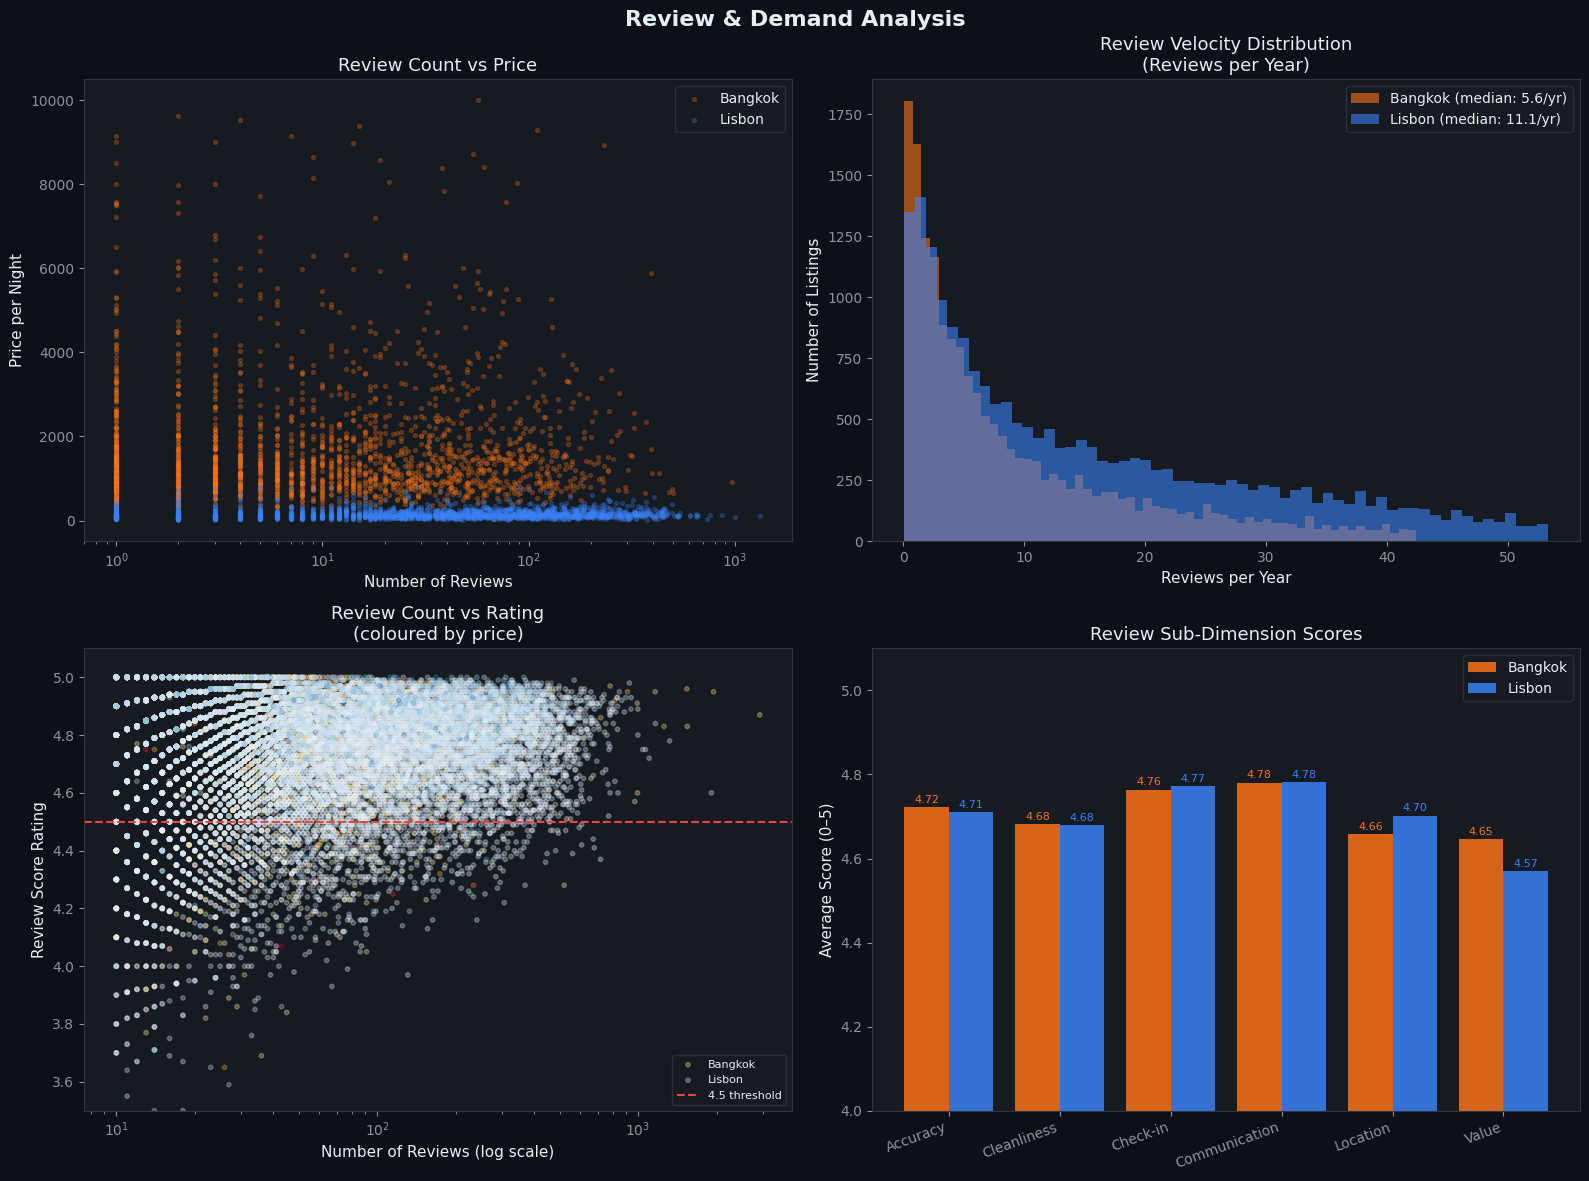


Chart 14 saved.


In [26]:

# CHART 14: Review Count vs Price & Demand Analysis


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Review & Demand Analysis", fontsize=16, fontweight="bold")

# --- Review count vs price scatter ---
ax1 = axes[0, 0]
for df, city, color in [(bkk, "Bangkok", COLORS["bangkok"]),
                         (lis, "Lisbon",  COLORS["lisbon"])]:
    sample = df[(df["price"].notna()) &
                (df["number_of_reviews"] > 0)].sample(
                    min(2000, len(df)), random_state=42)
    price_cap = 10000 if city == "Bangkok" else 800
    sample = sample[sample["price"] <= price_cap]
    ax1.scatter(sample["number_of_reviews"], sample["price"],
                alpha=0.25, s=8, color=color, label=city)

ax1.set_title("Review Count vs Price")
ax1.set_xlabel("Number of Reviews")
ax1.set_ylabel("Price per Night")
ax1.legend()
ax1.set_xscale("log")

# --- Review velocity distribution ---
ax2 = axes[0, 1]
for df, city, color in [(bkk, "Bangkok", COLORS["bangkok"]),
                         (lis, "Lisbon",  COLORS["lisbon"])]:
    rv = df["review_velocity"].dropna()
    rv = rv[rv <= rv.quantile(0.95)]
    ax2.hist(rv, bins=60, color=color, alpha=0.6,
             label=f"{city} (median: {rv.median():.1f}/yr)",
             edgecolor="none")

ax2.set_title("Review Velocity Distribution\n(Reviews per Year)")
ax2.set_xlabel("Reviews per Year")
ax2.set_ylabel("Number of Listings")
ax2.legend()

print("Review Velocity Summary:")
for df, city in [(bkk, "Bangkok"), (lis, "Lisbon")]:
    rv = df["review_velocity"].dropna()
    print(f"\n{city}:")
    print(f"  Median review velocity: {rv.median():.1f} reviews/year")
    print(f"  Mean review velocity:   {rv.mean():.1f} reviews/year")
    print(f"  % with >20 reviews/yr:  {(rv > 20).mean()*100:.1f}%")

# --- High review count, low score listings ---
ax3 = axes[1, 0]
for df, city, color in [(bkk, "Bangkok", COLORS["bangkok"]),
                         (lis, "Lisbon",  COLORS["lisbon"])]:
    df_plot = df[(df["number_of_reviews"] >= 10) &
                 df["review_scores_rating"].notna() &
                 df["price"].notna()].copy()
    price_cap = 10000 if city == "Bangkok" else 800
    df_plot = df_plot[df_plot["price"] <= price_cap]

    sc = ax3.scatter(df_plot["number_of_reviews"],
                     df_plot["review_scores_rating"],
                     c=df_plot["price"],
                     cmap="YlOrRd" if city == "Bangkok" else "Blues",
                     alpha=0.3, s=10, label=city)

ax3.axhline(4.5, color="#ef4444", linewidth=1.5,
            linestyle="--", label="4.5 threshold")
ax3.set_title("Review Count vs Rating\n(coloured by price)")
ax3.set_xlabel("Number of Reviews (log scale)")
ax3.set_ylabel("Review Score Rating")
ax3.set_xscale("log")
ax3.legend(fontsize=8)
ax3.set_ylim(3.5, 5.1)

# High-review, low-score listings
print("\nHigh-review (>50), low-score (<4.5) listings:")
for df, city in [(bkk, "Bangkok"), (lis, "Lisbon")]:
    flagged = df[(df["number_of_reviews"] > 50) &
                 (df["review_scores_rating"] < 4.5)]
    print(f"  {city}: {len(flagged)} listings")
    if len(flagged) > 0:
        print(f"    Median price:     {flagged['price'].median():.0f}")
        print(f"    Median occupancy: {flagged['occupancy_rate'].median():.1f}%")

# --- Review sub-dimension comparison detailed ---
ax4 = axes[1, 1]
sub_dims = ["accuracy", "cleanliness", "checkin",
            "communication", "location", "value"]
dim_labels = ["Accuracy", "Cleanliness", "Check-in",
              "Communication", "Location", "Value"]

bkk_means = [bkk[f"review_scores_{d}"].mean() for d in sub_dims]
lis_means  = [lis[f"review_scores_{d}"].mean() for d in sub_dims]

x = np.arange(len(sub_dims))
ax4.bar(x - 0.2, bkk_means, 0.4, color=COLORS["bangkok"],
        alpha=0.85, label="Bangkok")
ax4.bar(x + 0.2, lis_means, 0.4, color=COLORS["lisbon"],
        alpha=0.85, label="Lisbon")
ax4.set_xticks(x)
ax4.set_xticklabels(dim_labels, rotation=20, ha="right")
ax4.set_title("Review Sub-Dimension Scores")
ax4.set_ylabel("Average Score (0–5)")
ax4.set_ylim(4.0, 5.1)
ax4.legend()

for i, (b, l) in enumerate(zip(bkk_means, lis_means)):
    ax4.text(i - 0.2, b + 0.01, f"{b:.2f}", ha="center",
             fontsize=8, color=COLORS["bangkok"])
    ax4.text(i + 0.2, l + 0.01, f"{l:.2f}", ha="center",
             fontsize=8, color=COLORS["lisbon"])

print("\nReview Sub-dimension Comparison:")
for dim, b, l in zip(dim_labels, bkk_means, lis_means):
    print(f"  {dim:<15} Bangkok: {b:.3f}  Lisbon: {l:.3f}  "
          f"Diff: {b-l:+.3f}")

plt.tight_layout()
plt.savefig("notebooks/chart14_review_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 14 saved.")


Price Tier Summary:

Bangkok:
  Budget     n=5,819  occ=21.1%  rev=฿21,483
  Mid-range  n=11,636  occ=24.6%  rev=฿73,168
  Premium    n=5,818  occ=24.8%  rev=฿187,642

Lisbon:
  Budget     n=5,368  occ=36.8%  rev=€6,484
  Mid-range  n=10,755  occ=34.0%  rev=€13,493
  Premium    n=5,343  occ=33.6%  rev=€30,345


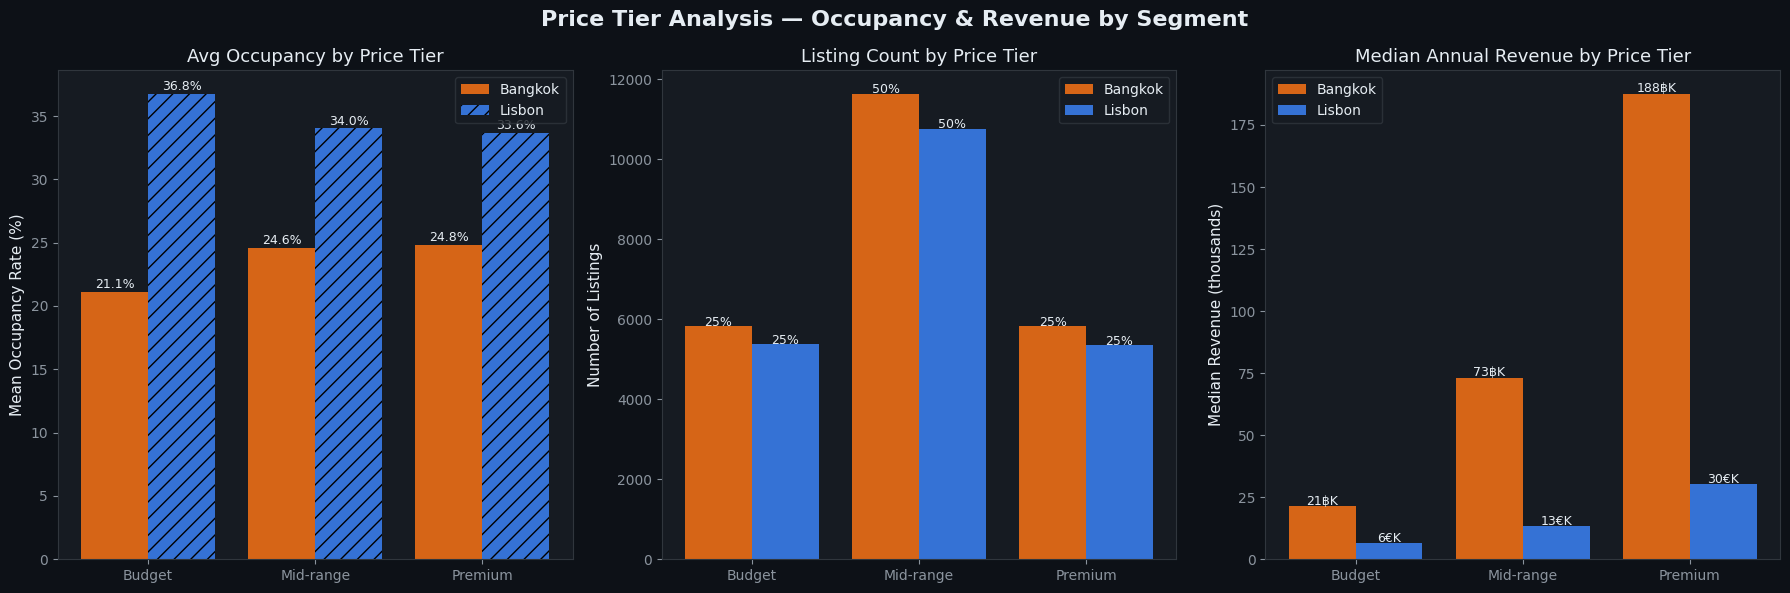


Chart 15 saved.


In [27]:

# CHART 15: Price Tier Performance — Occupancy & Revenue


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Price Tier Analysis — Occupancy & Revenue by Segment",
             fontsize=16, fontweight="bold")

tier_order = ["Budget", "Mid-range", "Premium"]
tier_colors = [COLORS["positive"], COLORS["accent"], COLORS["negative"]]

# Occupancy by tier
ax1 = axes[0]
for city, df_city, hatch in [("Bangkok", bkk, ""), ("Lisbon", lis, "//")]:
    tier_occ = df_city.groupby("price_tier")["occupancy_rate"].mean()
    vals = [tier_occ.get(t, 0) for t in tier_order]
    x = np.arange(len(tier_order))
    offset = -0.2 if city == "Bangkok" else 0.2
    color  = COLORS["bangkok"] if city == "Bangkok" else COLORS["lisbon"]
    bars = ax1.bar(x + offset, vals, 0.4, color=color,
                   alpha=0.85, label=city, hatch=hatch)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=9)

ax1.set_xticks(np.arange(len(tier_order)))
ax1.set_xticklabels(tier_order)
ax1.set_title("Avg Occupancy by Price Tier")
ax1.set_ylabel("Mean Occupancy Rate (%)")
ax1.legend()

# Listing count by tier
ax2 = axes[1]
for city, df_city in [("Bangkok", bkk), ("Lisbon", lis)]:
    tier_cnt = df_city["price_tier"].value_counts()
    vals = [tier_cnt.get(t, 0) for t in tier_order]
    pct  = [v / sum(vals) * 100 for v in vals]
    x = np.arange(len(tier_order))
    offset = -0.2 if city == "Bangkok" else 0.2
    color  = COLORS["bangkok"] if city == "Bangkok" else COLORS["lisbon"]
    bars = ax2.bar(x + offset, vals, 0.4, color=color,
                   alpha=0.85, label=city)
    for bar, p in zip(bars, pct):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f"{p:.0f}%", ha="center", fontsize=9)

ax2.set_xticks(np.arange(len(tier_order)))
ax2.set_xticklabels(tier_order)
ax2.set_title("Listing Count by Price Tier")
ax2.set_ylabel("Number of Listings")
ax2.legend()

# Median revenue by tier
ax3 = axes[2]
for city, df_city, scale, sym in [
    ("Bangkok", bkk, 1000, "฿K"),
    ("Lisbon",  lis,  1000, "€K")
]:
    tier_rev = df_city.groupby("price_tier")["estimated_annual_revenue"].median()
    vals = [tier_rev.get(t, 0) / scale for t in tier_order]
    x = np.arange(len(tier_order))
    offset = -0.2 if city == "Bangkok" else 0.2
    color  = COLORS["bangkok"] if city == "Bangkok" else COLORS["lisbon"]
    bars = ax3.bar(x + offset, vals, 0.4, color=color,
                   alpha=0.85, label=city)
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val:.0f}{sym}", ha="center", fontsize=9)

ax3.set_xticks(np.arange(len(tier_order)))
ax3.set_xticklabels(tier_order)
ax3.set_title("Median Annual Revenue by Price Tier")
ax3.set_ylabel("Median Revenue (thousands)")
ax3.legend()

print("\nPrice Tier Summary:")
for city, df_city, sym in [("Bangkok", bkk, "฿"), ("Lisbon", lis, "€")]:
    print(f"\n{city}:")
    for tier in tier_order:
        t_data = df_city[df_city["price_tier"] == tier]
        print(f"  {tier:<10} n={len(t_data):,}  "
              f"occ={t_data['occupancy_rate'].mean():.1f}%  "
              f"rev={sym}{t_data['estimated_annual_revenue'].median():,.0f}")

plt.tight_layout()
plt.savefig("notebooks/chart15_price_tiers.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 15 saved.")

In [29]:
#STATISTICAL ANALYSIS

from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, f_oneway, shapiro, levene
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

print("Statistical libraries loaded.")
print("\n" + " "*60)
print("ASSUMPTION CHECKS — NORMALITY (Shapiro-Wilk on samples)")
print(" # =============================================================================
# H1: Entire-home listings command significantly higher prices than private rooms
# =============================================================================

print("="*60)
print("HYPOTHESIS 1: Entire Home vs Private Room Prices")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H1: Entire Home vs Private Room — Price Comparison",
             fontsize=14, fontweight="bold")

for ax, city, df_city, color, currency, cap in [
    (axes[0], "Bangkok", bkk, COLORS["bangkok"], "฿", 8000),
    (axes[1], "Lisbon",  lis, COLORS["lisbon"],  "€", 600)
]:
    entire = df_city[df_city["room_type"] == "Entire home/apt"]["price"].dropna()
    private = df_city[df_city["room_type"] == "Private room"]["price"].dropna()

    # Mann-Whitney U test
    stat, p = mannwhitneyu(entire, private, alternative="greater")

    # Effect size: rank-biserial correlation
    n1, n2 = len(entire), len(private)
    r = 1 - (2 * stat) / (n1 * n2)

    print(f"\n{city}:")
    print(f"  Entire home  — median: {currency}{entire.median():,.0f}  "
          f"n={n1:,}")
    print(f"  Private room — median: {currency}{private.median():,.0f}  "
          f"n={n2:,}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.2e}")
    print(f"  Effect size (rank-biserial r): {r:.3f}")
    print(f"  Interpretation: {'Large' if abs(r)>0.5 else 'Medium' if abs(r)>0.3 else 'Small'} effect")
    print(f"  Result: {'REJECT H0 — significant difference' if p < 0.05 else 'FAIL TO REJECT H0'}")

    # Visualization
    entire_cap  = entire[entire <= cap]
    private_cap = private[private <= cap]
    ax.hist(entire_cap,  bins=60, alpha=0.7, color=color,
            label=f"Entire home (median: {currency}{entire.median():,.0f})")
    ax.hist(private_cap, bins=60, alpha=0.7, color=COLORS["accent"],
            label=f"Private room (median: {currency}{private.median():,.0f})")
    ax.axvline(entire.median(),  color=color,             linewidth=2, linestyle="--")
    ax.axvline(private.median(), color=COLORS["accent"],  linewidth=2, linestyle="--")
    ax.set_title(f"{city} — p={p:.2e}, r={r:.3f}")
    ax.set_xlabel(f"Price per Night ({currency})")
    ax.set_ylabel("Number of Listings")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("notebooks/chart16_h1_room_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 16 saved.")"*60)

# Shapiro-Wilk on samples (max 5000 for speed)
for city, df_city in [("Bangkok", bkk), ("Lisbon", lis)]:
    prices = df_city["price"].dropna()
    sample = prices.sample(min(5000, len(prices)), random_state=42)
    stat, p = shapiro(sample)
    print(f"\n{city} price distribution:")
    print(f"  Shapiro-Wilk W={stat:.4f}, p={p:.6f}")
    print(f"  Normal? {'Yes' if p > 0.05 else 'No — use non-parametric tests'}")
    print(f"  Skewness: {prices.skew():.3f}")
    print(f"  Kurtosis: {prices.kurtosis():.3f}")

print("NOTE: Both price distributions are non-normal (right-skewed).")
print("All hypothesis tests will use non-parametric alternatives:")
print("  Mann-Whitney U instead of t-test")
print("  Kruskal-Wallis instead of ANOVA")
print("  Effect sizes: rank-biserial r, eta-squared")


Statistical libraries loaded.

                                                            
ASSUMPTION CHECKS — NORMALITY (Shapiro-Wilk on samples)
                                                            

Bangkok price distribution:
  Shapiro-Wilk W=0.2087, p=0.000000
  Normal? No — use non-parametric tests
  Skewness: 53.239
  Kurtosis: 3080.711

Lisbon price distribution:
  Shapiro-Wilk W=0.2366, p=0.000000
  Normal? No — use non-parametric tests
  Skewness: 22.080
  Kurtosis: 648.723
NOTE: Both price distributions are non-normal (right-skewed).
All hypothesis tests will use non-parametric alternatives:
  Mann-Whitney U instead of t-test
  Kruskal-Wallis instead of ANOVA
  Effect sizes: rank-biserial r, eta-squared


                                                            
HYPOTHESIS 1: Entire Home vs Private Room Prices
                                                            

Bangkok:
  Entire home  — median: ฿1,500  n=16,498
  Private room — median: ฿1,090  n=6,263
  Mann-Whitney U=66431200, p=2.84e-244
  Effect size (rank-biserial r): -0.286
  Interpretation: Small effect
  Result: REJECT H0 — significant difference

Lisbon:
  Entire home  — median: €152  n=16,111
  Private room — median: €68  n=5,101
  Mann-Whitney U=71620768, p=0.00e+00
  Effect size (rank-biserial r): -0.743
  Interpretation: Large effect
  Result: REJECT H0 — significant difference


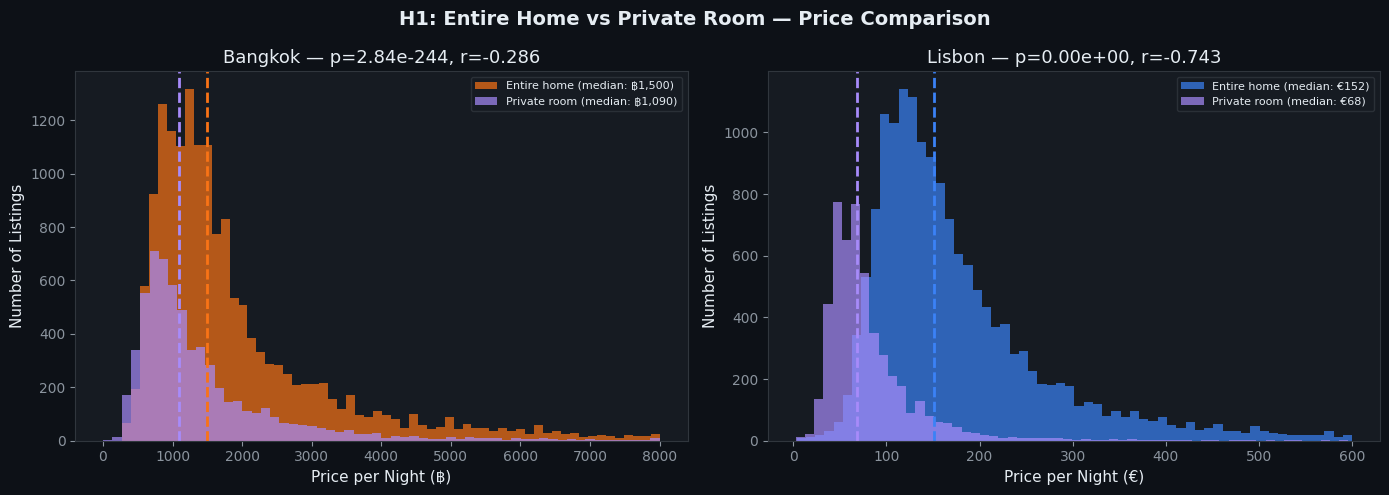


Chart 16 saved.


In [30]:
# H1: Entire-home listings command significantly higher prices than private rooms

print(" "*60)
print("HYPOTHESIS 1: Entire Home vs Private Room Prices")
print(" "*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H1: Entire Home vs Private Room — Price Comparison",
             fontsize=14, fontweight="bold")

for ax, city, df_city, color, currency, cap in [
    (axes[0], "Bangkok", bkk, COLORS["bangkok"], "฿", 8000),
    (axes[1], "Lisbon",  lis, COLORS["lisbon"],  "€", 600)
]:
    entire = df_city[df_city["room_type"] == "Entire home/apt"]["price"].dropna()
    private = df_city[df_city["room_type"] == "Private room"]["price"].dropna()

    # Mann-Whitney U test
    stat, p = mannwhitneyu(entire, private, alternative="greater")

    # Effect size: rank-biserial correlation
    n1, n2 = len(entire), len(private)
    r = 1 - (2 * stat) / (n1 * n2)

    print(f"\n{city}:")
    print(f"  Entire home  — median: {currency}{entire.median():,.0f}  "
          f"n={n1:,}")
    print(f"  Private room — median: {currency}{private.median():,.0f}  "
          f"n={n2:,}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.2e}")
    print(f"  Effect size (rank-biserial r): {r:.3f}")
    print(f"  Interpretation: {'Large' if abs(r)>0.5 else 'Medium' if abs(r)>0.3 else 'Small'} effect")
    print(f"  Result: {'REJECT H0 — significant difference' if p < 0.05 else 'FAIL TO REJECT H0'}")

    # Visualization
    entire_cap  = entire[entire <= cap]
    private_cap = private[private <= cap]
    ax.hist(entire_cap,  bins=60, alpha=0.7, color=color,
            label=f"Entire home (median: {currency}{entire.median():,.0f})")
    ax.hist(private_cap, bins=60, alpha=0.7, color=COLORS["accent"],
            label=f"Private room (median: {currency}{private.median():,.0f})")
    ax.axvline(entire.median(),  color=color,             linewidth=2, linestyle="--")
    ax.axvline(private.median(), color=COLORS["accent"],  linewidth=2, linestyle="--")
    ax.set_title(f"{city} — p={p:.2e}, r={r:.3f}")
    ax.set_xlabel(f"Price per Night ({currency})")
    ax.set_ylabel("Number of Listings")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("notebooks/chart16_h1_room_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 16 saved.")

                                                            
HYPOTHESIS 2: Superhost vs Non-Superhost Review Scores
                                                            

Bangkok:
  Superhost avg rating:     4.8578  (n=6,929)
  Non-Superhost avg rating: 4.5745  (n=10,540)
  Mean difference:          +0.2833
  Mann-Whitney U=48423545, p=4.01e-302
  Effect size (r):          -0.326
  Cohen's d (approx):       0.575
  Practical significance:   Medium
  Result: REJECT H0

Lisbon:
  Superhost avg rating:     4.8301  (n=7,709)
  Non-Superhost avg rating: 4.5525  (n=13,889)
  Mean difference:          +0.2776
  Mann-Whitney U=77615800, p=0.00e+00
  Effect size (r):          -0.450
  Cohen's d (approx):       0.719
  Practical significance:   Medium
  Result: REJECT H0


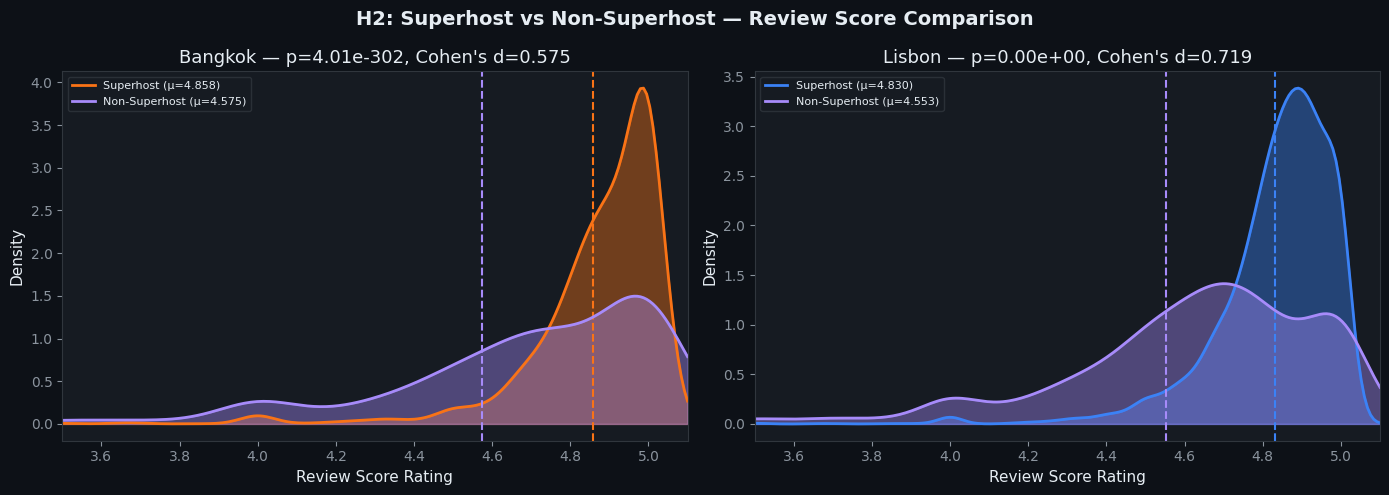


Chart 17 saved.


In [31]:

# H2: Superhost listings achieve higher review scores than non-superhost

print(" "*60)
print("HYPOTHESIS 2: Superhost vs Non-Superhost Review Scores")
print(" "*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H2: Superhost vs Non-Superhost — Review Score Comparison",
             fontsize=14, fontweight="bold")

for ax, city, df_city, color in [
    (axes[0], "Bangkok", bkk, COLORS["bangkok"]),
    (axes[1], "Lisbon",  lis, COLORS["lisbon"])
]:
    sh  = df_city[(df_city["host_is_superhost"]==True) &
                  df_city["review_scores_rating"].notna()]["review_scores_rating"]
    nsh = df_city[(df_city["host_is_superhost"]==False) &
                  df_city["review_scores_rating"].notna()]["review_scores_rating"]

    stat, p = mannwhitneyu(sh, nsh, alternative="greater")
    n1, n2 = len(sh), len(nsh)
    r = 1 - (2 * stat) / (n1 * n2)

    # Cohen's d (approximate for non-normal)
    pooled_std = np.sqrt((sh.std()**2 + nsh.std()**2) / 2)
    cohens_d = (sh.mean() - nsh.mean()) / pooled_std

    print(f"\n{city}:")
    print(f"  Superhost avg rating:     {sh.mean():.4f}  (n={n1:,})")
    print(f"  Non-Superhost avg rating: {nsh.mean():.4f}  (n={n2:,})")
    print(f"  Mean difference:          {sh.mean()-nsh.mean():+.4f}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.2e}")
    print(f"  Effect size (r):          {r:.3f}")
    print(f"  Cohen's d (approx):       {cohens_d:.3f}")
    print(f"  Practical significance:   "
          f"{'Large' if abs(cohens_d)>0.8 else 'Medium' if abs(cohens_d)>0.5 else 'Small'}")
    print(f"  Result: {'REJECT H0' if p < 0.05 else 'FAIL TO REJECT H0'}")

    # Visualization: KDE comparison
    from scipy.stats import gaussian_kde
    for data, label, lcolor in [(sh, "Superhost", color),
                                  (nsh, "Non-Superhost", COLORS["accent"])]:
        kde = gaussian_kde(data)
        x_range = np.linspace(3.5, 5.1, 200)
        ax.fill_between(x_range, kde(x_range), alpha=0.4, color=lcolor)
        ax.plot(x_range, kde(x_range), color=lcolor, linewidth=2,
                label=f"{label} (μ={data.mean():.3f})")
        ax.axvline(data.mean(), color=lcolor, linewidth=1.5, linestyle="--")

    ax.set_title(f"{city} — p={p:.2e}, Cohen's d={cohens_d:.3f}")
    ax.set_xlabel("Review Score Rating")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_xlim(3.5, 5.1)

plt.tight_layout()
plt.savefig("notebooks/chart17_h2_superhost.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 17 saved.")

                                                            
HYPOTHESIS 3: Review Count & Price Relationship
                                                            

Bangkok:
  >10 reviews  — median: ฿1,357  mean: ฿2,474  n=8,099
  ≤10 reviews  — median: ฿1,398  mean: ฿2,558  n=15,174
  Median diff:  ฿-41
  Mann-Whitney U=59240820, p=6.21e-06
  Effect size r=0.036
  Result: REJECT H0

Lisbon:
  >10 reviews  — median: €134  mean: €166  n=13,754
  ≤10 reviews  — median: €126  mean: €225  n=7,712
  Median diff:  €+8
  Mann-Whitney U=55961049, p=1.86e-11
  Effect size r=-0.055
  Result: REJECT H0


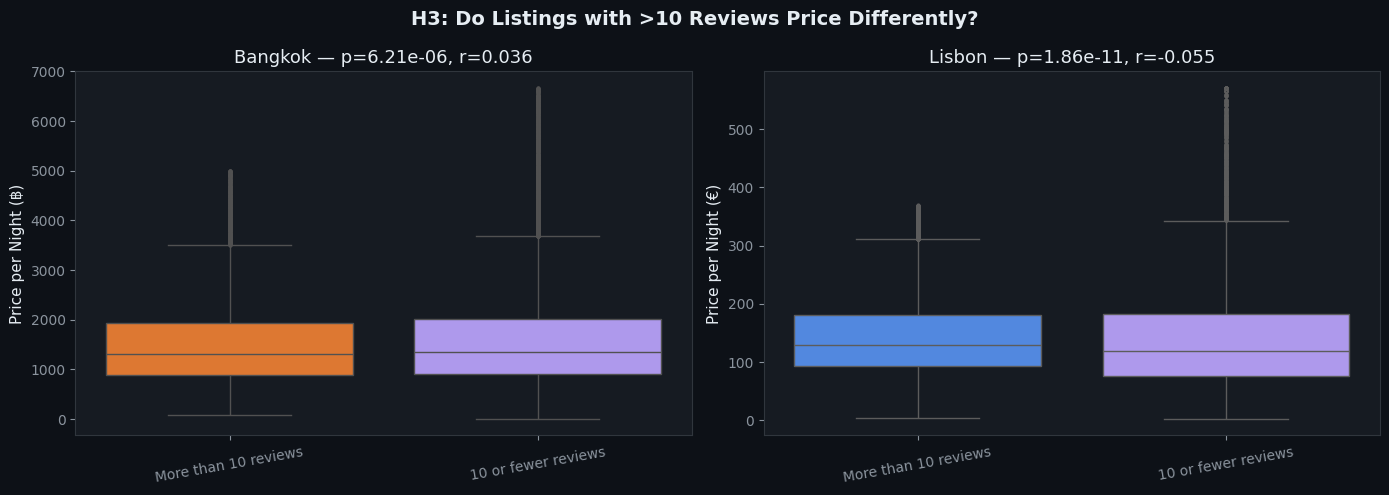


Chart 18 saved.


In [33]:
# H3: Listings with >10 reviews have significantly different prices


print(" "*60)
print("HYPOTHESIS 3: Review Count & Price Relationship")
print(" "*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H3: Do Listings with >10 Reviews Price Differently?",
             fontsize=14, fontweight="bold")

for ax, city, df_city, color, currency in [
    (axes[0], "Bangkok", bkk, COLORS["bangkok"], "฿"),
    (axes[1], "Lisbon",  lis, COLORS["lisbon"],  "€")
]:
    has_reviews = df_city[df_city["number_of_reviews"] > 10]["price"].dropna()
    few_reviews = df_city[df_city["number_of_reviews"] <= 10]["price"].dropna()

    stat, p = mannwhitneyu(has_reviews, few_reviews, alternative="two-sided")
    n1, n2 = len(has_reviews), len(few_reviews)
    r = 1 - (2 * stat) / (n1 * n2)

    print(f"\n{city}:")
    print(f"  >10 reviews  — median: {currency}{has_reviews.median():,.0f}  "
          f"mean: {currency}{has_reviews.mean():,.0f}  n={n1:,}")
    print(f"  ≤10 reviews  — median: {currency}{few_reviews.median():,.0f}  "
          f"mean: {currency}{few_reviews.mean():,.0f}  n={n2:,}")
    print(f"  Median diff:  {currency}{has_reviews.median()-few_reviews.median():+,.0f}")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.2e}")
    print(f"  Effect size r={r:.3f}")
    print(f"  Result: {'REJECT H0' if p < 0.05 else 'FAIL TO REJECT H0'}")

    # Box plot comparison
    plot_data = pd.DataFrame({
        "price": pd.concat([
            has_reviews[has_reviews <= has_reviews.quantile(0.95)],
            few_reviews[few_reviews <= few_reviews.quantile(0.95)]
        ]),
        "group": (["More than 10 reviews"] * len(has_reviews[has_reviews <= has_reviews.quantile(0.95)]) +
                  ["10 or fewer reviews"] * len(few_reviews[few_reviews <= few_reviews.quantile(0.95)]))
    })
    sns.boxplot(data=plot_data, x="group", y="price",
                palette=[color, COLORS["accent"]], ax=ax, fliersize=2)
    ax.set_title(f"{city} — p={p:.2e}, r={r:.3f}")
    ax.set_xlabel("")
    ax.set_ylabel(f"Price per Night ({currency})")
    ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig("notebooks/chart18_h3_reviews_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 18 saved.")

HYPOTHESIS 4: Neighbourhood Price Differences (Kruskal-Wallis)
                                                            

Bangkok (top 15 neighbourhoods):
  Kruskal-Wallis H=2792.63, p=0.00e+00
  Eta-squared (effect size): 0.1467
  Interpretation: Large effect
  Result: REJECT H0 — significant differences

  Neighbourhood median prices (top 15):
    Bang Sue                       ฿819
    Bang Na                        ฿890
    Suanluang                      ฿1,045
    Khlong San                     ฿1,086
    Phra Nakhon                    ฿1,103
    Chatu Chak                     ฿1,130
    Sathon                         ฿1,165
    Phra Khanong                   ฿1,184
    Din Daeng                      ฿1,190
    Huai Khwang                    ฿1,400
    Ratchathewi                    ฿1,588
    Khlong Toei                    ฿1,622
    Vadhana                        ฿1,828
    Bang Rak                       ฿1,890
    Parthum Wan                    ฿2,248

Lisbon (top 15 neighbo

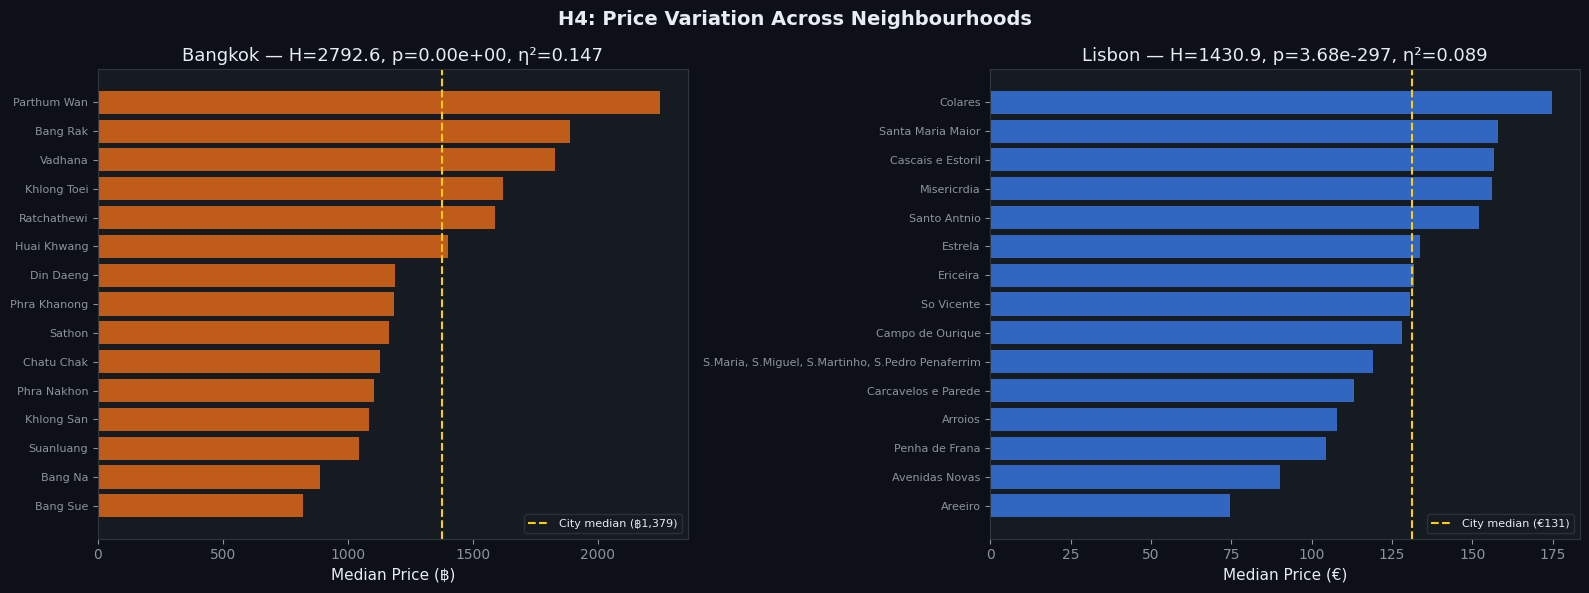


Chart 19 saved.


In [34]:

print("HYPOTHESIS 4: Neighbourhood Price Differences (Kruskal-Wallis)")
print(" "*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("H4: Price Variation Across Neighbourhoods",
             fontsize=14, fontweight="bold")

for ax, city, df_city, color, currency in [
    (axes[0], "Bangkok", bkk, COLORS["bangkok"], "฿"),
    (axes[1], "Lisbon",  lis, COLORS["lisbon"],  "€")
]:
    # Use top 15 neighbourhoods by count for cleaner analysis
    top_n = (df_city.groupby("neighbourhood_cleansed")["listing_id"]
               .count().nlargest(15).index.tolist())
    df_top = df_city[df_city["neighbourhood_cleansed"].isin(top_n) &
                     df_city["price"].notna()]

    groups = [grp["price"].values
              for _, grp in df_top.groupby("neighbourhood_cleansed")]

    stat, p = kruskal(*groups)

    # Eta-squared effect size
    n = len(df_top)
    k = len(groups)
    eta_sq = (stat - k + 1) / (n - k)

    print(f"\n{city} (top 15 neighbourhoods):")
    print(f"  Kruskal-Wallis H={stat:.2f}, p={p:.2e}")
    print(f"  Eta-squared (effect size): {eta_sq:.4f}")
    print(f"  Interpretation: "
          f"{'Large' if eta_sq>0.14 else 'Medium' if eta_sq>0.06 else 'Small'} effect")
    print(f"  Result: {'REJECT H0 — significant differences' if p < 0.05 else 'FAIL TO REJECT H0'}")

    # Neighbourhood medians
    neigh_medians = (df_top.groupby("neighbourhood_cleansed")["price"]
                     .median().sort_values(ascending=True))
    print(f"\n  Neighbourhood median prices (top 15):")
    for n_name, price in neigh_medians.items():
        print(f"    {n_name:<30} {currency}{price:,.0f}")

    # Chart: median prices by neighbourhood
    bars = ax.barh(range(len(neigh_medians)), neigh_medians.values,
                   color=color, alpha=0.75, edgecolor="none")
    ax.set_yticks(range(len(neigh_medians)))
    ax.set_yticklabels(neigh_medians.index, fontsize=8)
    ax.set_title(f"{city} — H={stat:.1f}, p={p:.2e}, η²={eta_sq:.3f}")
    ax.set_xlabel(f"Median Price ({currency})")
    ax.axvline(df_city["price"].median(), color="#facc15",
               linewidth=1.5, linestyle="--",
               label=f"City median ({currency}{df_city['price'].median():,.0f})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("notebooks/chart19_h4_neighbourhoods.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 19 saved.")

HYPOTHESIS 5: Weekend vs Weekday Pricing (Calendar Data)
                                                            

Bangkok:
  Weekend availability rate: 68.06%
  Weekday availability rate: 68.72%
  Difference: -0.66 percentage points
  Mann-Whitney U=11246931036508, p=6.84e-98
  Effect size r=0.0066
  Result: REJECT H0
  Practical significance: Effect size r=0.0066 — Negligible

Lisbon:
  Weekend availability rate: 58.41%
  Weekday availability rate: 59.03%
  Difference: -0.63 percentage points
  Mann-Whitney U=8406560633677, p=1.13e-67
  Effect size r=0.0063
  Result: REJECT H0
  Practical significance: Effect size r=0.0063 — Negligible


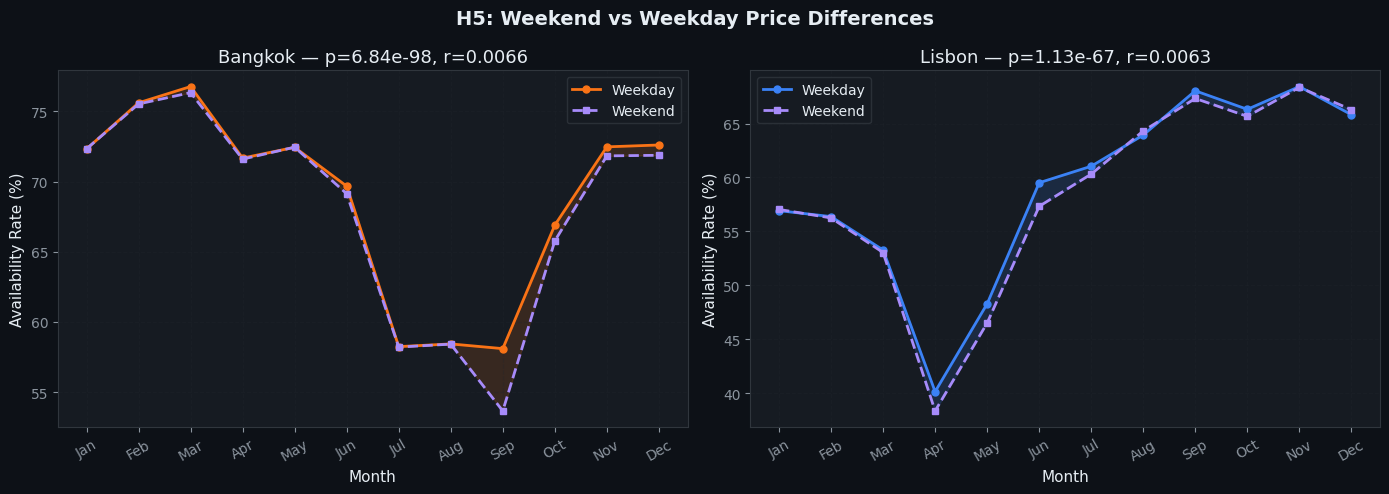


Chart 20 saved.


In [35]:

print("HYPOTHESIS 5: Weekend vs Weekday Pricing (Calendar Data)")
print(" "*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H5: Weekend vs Weekday Price Differences",
             fontsize=14, fontweight="bold")

# Use calendar data — need to join with listing prices
# We'll use availability as a demand proxy: lower availability = higher demand
for ax, city, color in [
    (axes[0], "bangkok", COLORS["bangkok"]),
    (axes[1], "lisbon",  COLORS["lisbon"])
]:
    cal_city = calendar[calendar["city"] == city].copy()

    weekend_avail = cal_city[cal_city["is_weekend"]==True]["available"].astype(int)
    weekday_avail = cal_city[cal_city["is_weekend"]==False]["available"].astype(int)

    stat, p = mannwhitneyu(weekend_avail, weekday_avail, alternative="two-sided")
    n1, n2 = len(weekend_avail), len(weekday_avail)
    r = 1 - (2 * stat) / (n1 * n2)

    weekend_rate = weekend_avail.mean() * 100
    weekday_rate = weekday_avail.mean() * 100

    print(f"\n{city.capitalize()}:")
    print(f"  Weekend availability rate: {weekend_rate:.2f}%")
    print(f"  Weekday availability rate: {weekday_rate:.2f}%")
    print(f"  Difference: {weekend_rate - weekday_rate:+.2f} percentage points")
    print(f"  Mann-Whitney U={stat:.0f}, p={p:.2e}")
    print(f"  Effect size r={r:.4f}")
    print(f"  Result: {'REJECT H0' if p < 0.05 else 'FAIL TO REJECT H0'}")
    print(f"  Practical significance: Effect size r={r:.4f} — "
          f"{'Negligible' if abs(r)<0.1 else 'Small' if abs(r)<0.3 else 'Medium'}")

    # Monthly weekend vs weekday availability
    monthly = cal_city.groupby(["month", "is_weekend"])["available"].mean() * 100
    monthly = monthly.unstack()
    monthly.columns = ["Weekday", "Weekend"]
    monthly.index = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"]

    ax.plot(range(12), monthly["Weekday"], color=color,
            linewidth=2, marker="o", markersize=5, label="Weekday")
    ax.plot(range(12), monthly["Weekend"], color=COLORS["accent"],
            linewidth=2, marker="s", markersize=5,
            linestyle="--", label="Weekend")
    ax.fill_between(range(12), monthly["Weekday"], monthly["Weekend"],
                    alpha=0.15, color=color)
    ax.set_xticks(range(12))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"],
                        rotation=30)
    ax.set_title(f"{city.capitalize()} — p={p:.2e}, r={r:.4f}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Availability Rate (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/chart20_h5_weekend.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart 20 saved.")

SECTION 5.3: CORRELATION MATRIX & OLS REGRESSION
                                                            


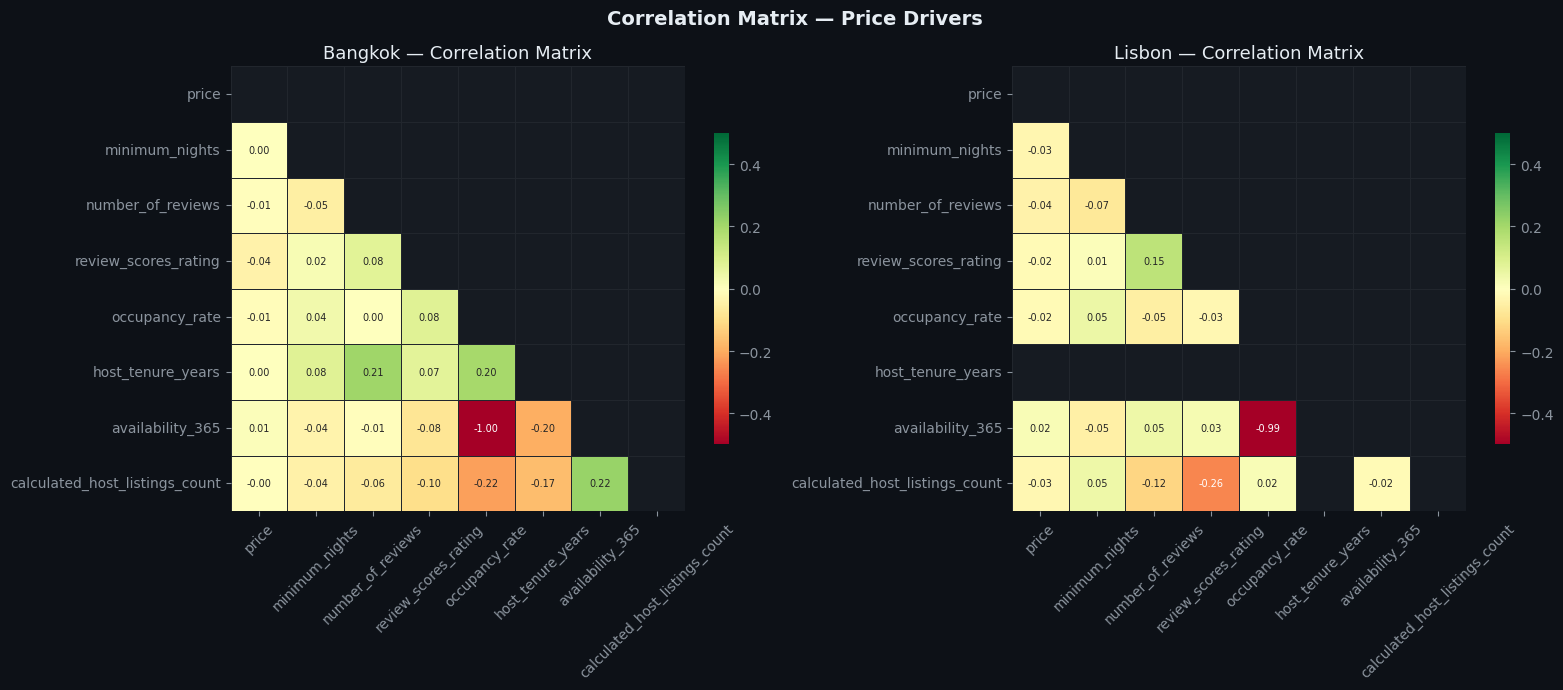


OLS REGRESSION — PRICE DRIVERS

--- Bangkok OLS Regression ---
  R-squared:       0.0127
  Adj R-squared:   0.0123
  F-statistic:     34.21  (p=2.68e-41)
  Observations:    15,952

  Coefficients (log-price model):
  Feature                                 Coef    p-value   Sig
  ------------------------------------------------------------
  minimum_nights                       -0.0016     0.0000   ***
  number_of_reviews                     0.0001     0.1419      
  review_scores_rating                  0.0499     0.0000   ***
  host_tenure_years                     0.0002     0.9036      
  availability_365                     -0.0005     0.0000   ***
  calculated_host_listings_count        0.0008     0.0000   ***

  VIF (multicollinearity check):
    host_tenure_years                   VIF=1.06
    number_of_reviews                   VIF=1.06
    review_scores_rating                VIF=1.02
    calculated_host_listings_count      VIF=1.02
    availability_365                    VIF

In [39]:

print("SECTION 5.3: CORRELATION MATRIX & OLS REGRESSION")
print(" "*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Correlation Matrix — Price Drivers", fontsize=14, fontweight="bold")

corr_cols = [
    "price", "accommodates", "bedrooms", "bathrooms", "beds",
    "minimum_nights", "number_of_reviews", "review_scores_rating",
    "occupancy_rate", "host_tenure_years", "availability_365",
    "calculated_host_listings_count"
]

for ax, city, df_city in [
    (axes[0], "Bangkok", bkk),
    (axes[1], "Lisbon",  lis)
]:
    available = [c for c in corr_cols if c in df_city.columns]
    corr = df_city[available].corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap="RdYlGn",
                center=0, vmin=-0.5, vmax=0.5,
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.5, linecolor="#21262d",
                cbar_kws={"shrink": 0.7})
    ax.set_title(f"{city} — Correlation Matrix")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("notebooks/chart21_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


# --- OLS Regression ---
print("\n" + "="*60)
print("OLS REGRESSION — PRICE DRIVERS")
print("="*60)

reg_features_bangkok = [
    "accommodates", "bedrooms", "bathrooms",
    "minimum_nights", "number_of_reviews",
    "review_scores_rating", "host_tenure_years",
    "availability_365", "calculated_host_listings_count"
]

reg_features_lisbon = [
    "accommodates", "bedrooms", "bathrooms",
    "minimum_nights", "number_of_reviews",
    "review_scores_rating",
    "availability_365", "calculated_host_listings_count"
]

for city, df_city, currency, reg_features in [
    ("Bangkok", bkk, "฿", reg_features_bangkok),
    ("Lisbon",  lis, "€", reg_features_lisbon)
]:
    print(f"\n--- {city} OLS Regression ---")

    available = [c for c in reg_features if c in df_city.columns]
    df_reg = df_city[["price"] + available].dropna().copy()

    if len(df_reg) == 0:
        print(f"  No data available after dropna — skipping {city}")
        continue

    cap = df_reg["price"].quantile(0.99)
    df_reg = df_reg[df_reg["price"] <= cap]
    df_reg["log_price"] = np.log1p(df_reg["price"])

    X = sm.add_constant(df_reg[available])
    y = df_reg["log_price"]

    model = sm.OLS(y, X).fit()

    print(f"  R-squared:       {model.rsquared:.4f}")
    print(f"  Adj R-squared:   {model.rsquared_adj:.4f}")
    print(f"  F-statistic:     {model.fvalue:.2f}  (p={model.f_pvalue:.2e})")
    print(f"  Observations:    {int(model.nobs):,}")
    print(f"\n  Coefficients (log-price model):")
    print(f"  {'Feature':<35} {'Coef':>8} {'p-value':>10} {'Sig':>5}")
    print(f"  {'-'*60}")
    for feat in available:
        coef = model.params.get(feat, np.nan)
        pval = model.pvalues.get(feat, np.nan)
        sig  = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {feat:<35} {coef:>8.4f} {pval:>10.4f} {sig:>5}")

    print(f"\n  VIF (multicollinearity check):")
    vif_data = pd.DataFrame({
        "Feature": available,
        "VIF": [variance_inflation_factor(X.values, i+1)
                for i in range(len(available))]
    }).sort_values("VIF", ascending=False)
    for _, row in vif_data.iterrows():
        flag = " ⚠ HIGH" if row["VIF"] > 10 else ""
        print(f"    {row['Feature']:<35} VIF={row['VIF']:.2f}{flag}")

print("\nRegression complete.")

print("\nChart 21 saved.")